In [76]:
import pandas as pd
import os
import glob
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re


folders_testing = [f for f in glob.glob(os.path.join('results', '*TESTING*')) if os.path.isdir(f)]

combined_testing = []

for item in folders_testing:
    # Extract middle numbers: after HH_ML_LM_HL_LH_ and before _NEW_TESTING
    mid_match = re.search(r'(\d+)_(\d+)_(\d+)_(\d+)_NEW_TESTING', item)
    
    # Extract end numbers: after final double underscore "__"
    end_match = re.search(r'__(\d+)_(\d+)___(\d+)$', item)
    
    if mid_match and end_match:
        mid_nums = tuple(map(int, mid_match.groups()))
        end_nums = tuple(map(int, end_match.groups()))
        combined_nums = mid_nums[2:-1] + end_nums[:-1]  # Full key for sorting
        combined_testing.append(combined_nums)

# Sort the entries based on the combined numerical key
set(combined_testing)

{(2, 12, 3),
 (2, 12, 6),
 (2, 12, 9),
 (2, 24, 6),
 (2, 24, 12),
 (2, 24, 18),
 (2, 42, 10),
 (2, 42, 21),
 (2, 42, 31)}

In [74]:
# Find all folders with 'WINDOW' in their name under 'results'
folders_window = [f for f in glob.glob(os.path.join('results', '*WINDOW*')) if os.path.isdir(f)]

combined_window = []

for item in folders_window:
    # Extract middle numbers: 4 integers before '_NEW_WINDOW'
    mid_match = re.search(r'(\d+)_(\d+)_(\d+)_(\d+)_NEW_WINDOW', item)

    # Extract end numbers: 3 integers after the last "__"
    end_match = re.search(r'__(\d+)_(\d+)_(\d+)___\d+$', item)

    if mid_match and end_match:
        mid_nums = tuple(map(int, mid_match.groups()))      # e.g. (10, 1, 12, 12)
        end_nums = tuple(map(int, end_match.groups()))      # e.g. (12, 3, 43200)
        combined_nums = mid_nums[2:-1] + end_nums[:-1]                 # Full key for sorting
        combined_window.append(combined_nums)

# Sort the entries based on the combined numerical key
set(combined_window)

{(2, 12, 3),
 (2, 12, 6),
 (2, 12, 9),
 (2, 48, 12),
 (2, 48, 24),
 (2, 48, 36),
 (2, 84, 21),
 (2, 84, 42),
 (2, 84, 63),
 (2, 144, 36),
 (2, 144, 72),
 (2, 144, 108),
 (2, 168, 42),
 (2, 168, 84),
 (2, 168, 126),
 (2, 360, 90),
 (2, 360, 180),
 (2, 360, 270),
 (3, 84, 21),
 (3, 84, 42),
 (3, 84, 63),
 (3, 168, 84),
 (4, 3, 1),
 (4, 3, 2),
 (4, 6, 3),
 (4, 6, 4),
 (4, 9, 4),
 (4, 9, 6),
 (4, 84, 42),
 (4, 168, 84),
 (6, 3, 1),
 (6, 3, 2),
 (6, 6, 3),
 (6, 6, 4),
 (6, 9, 4),
 (6, 9, 6),
 (6, 12, 3),
 (6, 12, 6),
 (6, 12, 9),
 (6, 48, 12),
 (6, 48, 24),
 (6, 48, 36),
 (6, 144, 36),
 (6, 144, 72),
 (6, 144, 108),
 (12, 3, 1),
 (12, 3, 2),
 (12, 6, 3),
 (12, 6, 4),
 (12, 9, 4),
 (12, 9, 6),
 (12, 12, 3),
 (12, 12, 6),
 (12, 12, 9),
 (12, 48, 12),
 (12, 48, 24),
 (12, 48, 36)}

In [50]:
folders_window[:4]

['results\\A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WINDOW_LL_HL_ML_LH_LL__12_3_43200___0',
 'results\\A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WINDOW_LL_HL_ML_LH_LL__12_6_43200___0',
 'results\\A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WINDOW_LL_HL_ML_LH_LL__12_9_43200___0',
 'results\\A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_3_NEW_WINDOW_LL_HL_ML_LH_LL__3_1_43200___0']

In [1]:
def get_similar_districts_from_path(path_string):
    try:
        # Split the experiment name
        parts = path_string.split('__')
        
        # Get target info
        header = parts[0]  # e.g., 'E_15_LL_LM'
        target_district = header.split('_')[0]  # 'E'
        target_init_state = header.split('_')[2]  # 'LL'
        target_final_state = header.split('_')[3]  # 'LM'

        # Get district state mapping
        state_mapping_str = parts[1]  # e.g., 'LM_LL_LM_LL_LL'
        district_states = state_mapping_str.split('_')

        # Districts in order
        district_names = ['A', 'B', 'C', 'D', 'E']

        if len(district_states) < 5:
            raise ValueError("Expected at least 5 states for districts A–E. Got: " + str(district_states))

        # Map district to state
        district_state_map = dict(zip(district_names, district_states[:5]))

        # Find similar districts (excluding the target itself)
        similar_initial = [d for d, s in district_state_map.items() if s == target_init_state and d != target_district]
        similar_final = [d for d, s in district_state_map.items() if s == target_final_state and d != target_district]

        return {
            "target_district": target_district,
            "target_init_state": target_init_state,
            "target_final_state": target_final_state,
            "initial_similar_districts": similar_initial,
            "final_similar_districts": similar_final
        }

    except Exception as e:
        print(f"Error parsing: {e}")
        return None


def analyze_experiment(results_df, results_id):
    try:
        info_state = get_similar_districts_from_path(results_id)
        tgt_client = results_id[0]

        top_ranked = results_df[results_df['rank'] == 1]

        summary = top_ranked.groupby(['epoch', 'label', 'client_2']).size().reset_index(name='count')
        summary['district_letter'] = summary['client_2'].str.extract(r'District_([A-Z])')

        summary['epoch'] = pd.to_numeric(summary['epoch'], errors='coerce')
        summary['label'] = pd.to_numeric(summary['label'], errors='coerce')
        summary = summary.dropna(subset=['district_letter', 'epoch', 'label'])

        # Final-only match
        summary['match_final_only'] = summary['district_letter'].isin(info_state['final_similar_districts'])

        # Warm-up rule
        def match_with_warmup(row):
            if row['label'] < 3:
                return row['district_letter'] in info_state['initial_similar_districts']
            else:
                return row['district_letter'] in info_state['final_similar_districts']

        summary['match_warmup_rule'] = summary.apply(match_with_warmup, axis=1)

        # Summarize results
        total_final = summary['match_final_only'].sum()
        total_warmup = summary['match_warmup_rule'].sum()

        matches_per_epoch = summary.groupby('epoch')[['match_final_only', 'match_warmup_rule']].sum().reset_index()
        max_final = matches_per_epoch['match_final_only'].max()
        max_warmup = matches_per_epoch['match_warmup_rule'].max()

        matches_per_epoch['experiment'] = results_id
        matches_per_epoch['max_final_matches'] = max_final
        matches_per_epoch['max_warmup_matches'] = max_warmup

        return {
            'experiment': results_id,
            'total_final_matches': total_final,
            'total_warmup_matches': total_warmup,
            'max_final_matches': max_final,
            'max_warmup_matches': max_warmup
        }

    except Exception as e:
        return {'experiment': results_id, 'error': str(e)}


def extract_exp_info(exp_id):
    try:
        parts = exp_id.split('__')
        target_header = parts[0]                     # 'E_15_LL_LM'
        mapping = parts[1]                           # 'LM_LL_LM_LL_LL'

        target_district = target_header.split('_')[0]     # 'E'
        node_id = target_header.split('_')[1]             # '15'
        init_state = target_header.split('_')[2]          # 'LL'
        final_state = target_header.split('_')[3]         # 'LM'

        aux_exp1 = exp_id.split('__')[-1]
        aux_exp2 = exp_id.split('__')[-2]

        return pd.Series([
            f"{target_district}_{node_id}",         # 'E_15'
            f"{init_state}_{final_state}",          # 'LL_LM'
            mapping[:14],                                 # 'LM_LL_LM_LL_LL'
            f"{aux_exp2}_{aux_exp1}"
        ])
    except Exception as e:
        print(f"Failed parsing exp_id: {exp_id} — {e}")
        return pd.Series([None, None, None])


def find_similar(row):
    match_cols = [col for col in ['A', 'B', 'C', 'D', 'E'] if row[col] == row['target_final_state']]
    return '_'.join(match_cols)


def compute_best_cases(df_results):

    df_results[['target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']] = (
        df_results['experiment'].apply(extract_exp_info)
    )
     
    # Get max warmup match for each unique config
    idx = df_results.groupby(
        ['target_district_node', 'target_init_final_state', 'initial_state_mapping']
    )['total_final_matches'].idxmax()
    
    df_best_per_config = df_results.loc[idx].reset_index(drop=True)
    
    df_best_per_config['correct_epochs'] = df_best_per_config['total_final_matches'] / 24
    
    df_best_per_config['target_district'] = df_best_per_config['target_district_node'].str.split('_').str[0]
    df_best_per_config['target_initial_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-2]
    df_best_per_config['target_final_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-1]
    
    df_best_per_config[['A', 'B', 'C', 'D', 'E']] = df_best_per_config['initial_state_mapping'].str.split('_', expand = True)
    
    df_best_per_config.drop(columns = ['target_district_node', 'initial_state_mapping', 'target_init_final_state'], inplace = True)
    
    df_best_per_config['similar_districts'] = df_best_per_config.apply(find_similar, axis=1)
    
    # Optional: sort by warmup performance
    df_best_per_config = df_best_per_config[df_best_per_config['similar_districts'] != '']
    df_best_per_config = df_best_per_config.sort_values(by=['total_final_matches', 'max_final_matches', 'similar_districts'], ascending=[False, False, True])

    return df_best_per_config

In [2]:
import pandas as pd
import os
import glob
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def compute_results(experiment_id = 'NEW_WINDOW', metrics = ['autocorr']):

    results_path = 'results'
    
    # Get all folder paths
    folders_with_rep = [f for f in glob.glob(os.path.join(results_path, F'*{experiment_id}*')) if os.path.isdir(f)]

    
    # Group by base experiment (strip off last suffix) -> for when have exp. repetition under diferent seeds
    grouped_exps = defaultdict(list)
    for path in folders_with_rep:
        folder_name = os.path.basename(path)
        if '__' in folder_name:
            base = '__'.join(folder_name.split('__')[:-1])
            grouped_exps[base].append(path)
        else:
            grouped_exps[folder_name].append(path)


    # Run analysis for each experiment folder
    epoch_results = []
    all_results = []
    for base_name, group_paths in grouped_exps.items():
        for path in group_paths:
            exp_name = os.path.basename(path)

            # Load data
            path_data = f"{results_path}/{exp_name}/Baseline_proto.parquet"
            results_proto = pd.read_parquet(path_data)
            results_tgt = results_proto[results_proto['client_1'].str.contains(f'_{exp_name[0]}_')].drop(columns=['client_1'])
    
            # Compute rank based on the metrics
            results_tgt['test_metric'] = results_tgt[metrics[0]]
            if len(metrics) != 1:
                for metric in metrics[1:]:
                    results_tgt['test_metric'] += results_tgt[metric] 
            results_tgt['rank'] = results_tgt.groupby(['epoch', 'label'])['test_metric'].rank(method='dense', ascending=True)

            # Analyse the results over experiments
            exp_result = analyze_experiment(results_df = results_tgt, results_id = exp_name)
            all_results.append(exp_result.copy())
            
            # Analyse the results per epoch
            case_epochs = []
            for epoch in results_proto['epoch'].unique():
                data_epoch = results_tgt[results_tgt['epoch'] == epoch]
                result = analyze_experiment(results_df = data_epoch, results_id = exp_name)
                result['epoch'] = epoch

                case_epochs.append(result)
                
                result_df = pd.DataFrame(result, index = [0])
                best_epochs = compute_best_cases(result_df)
                epoch_results.append(best_epochs.copy())

    exp_df = pd.DataFrame(all_results)
    best_cases = compute_best_cases(exp_df)
    

    return pd.concat(epoch_results, ignore_index = True), best_cases, exp_df, epoch_results

In [4]:
epochs_results_window_cosine, best_results_window_cosine,  exp_df_cosine, epoch_results_cosine = compute_results(experiment_id = 'NEW_WINDOW', metrics = ['cosine'])

In [32]:
exp_df_cosine

,experiment,total_final_matches,total_warmup_matches,max_final_matches,max_warmup_matches,target_district_node,target_init_final_state,initial_state_mapping,exp_id
0,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,0,2,0,1,A_62,LL_LH,LL_HL_ML_LH_LL,12_3_43200__0
1,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,9,16,2,3,A_62,LL_LH,LL_HL_ML_LH_LL,12_6_43200__0
2,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,0,10,0,1,A_62,LL_LH,LL_HL_ML_LH_LL,12_9_43200__0
3,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_3_NEW_WINDO...,0,10,0,1,A_62,LL_LH,LL_HL_ML_LH_LL,3_1_43200__0
4,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_3_NEW_WINDO...,0,0,0,0,A_62,LL_LH,LL_HL_ML_LH_LL,3_2_43200__0
...,...,...,...,...,...,...,...,...,...
1434,A_62_LL_ML__LL_MM_HL_ML_LM_10_1_6_48_NEW_WINDO...,81,81,9,9,A_62,LL_ML,LL_MM_HL_ML_LM,48_36_21600__0
1435,A_62_LL_ML__LL_MM_HL_ML_LM_10_1_6_6_NEW_WINDOW...,83,73,9,8,A_62,LL_ML,LL_MM_HL_ML_LM,6_3_21600__0
1436,A_62_LL_ML__LL_MM_HL_ML_LM_10_1_6_6_NEW_WINDOW...,12,12,3,3,A_62,LL_ML,LL_MM_HL_ML_LM,6_4_21600__0
1437,A_62_LL_ML__LL_MM_HL_ML_LM_10_1_6_9_NEW_WINDOW...,96,96,10,10,A_62,LL_ML,LL_MM_HL_ML_LM,9_4_21600__0


In [7]:
data_exps = []
for metric in ['cosine', 'wavelet', 'dft', 'autocorr']:
    aux_exps = compute_results(experiment_id = 'NEW_WINDOW', metrics = [metric])
    data_exps.append(aux_exps)

In [30]:
import pickle

# Save (serialize) the list of lists to a file
with open('results/imgs/hyperparams_baseline.pkl', 'wb') as f:
    pickle.dump(data_exps, f)

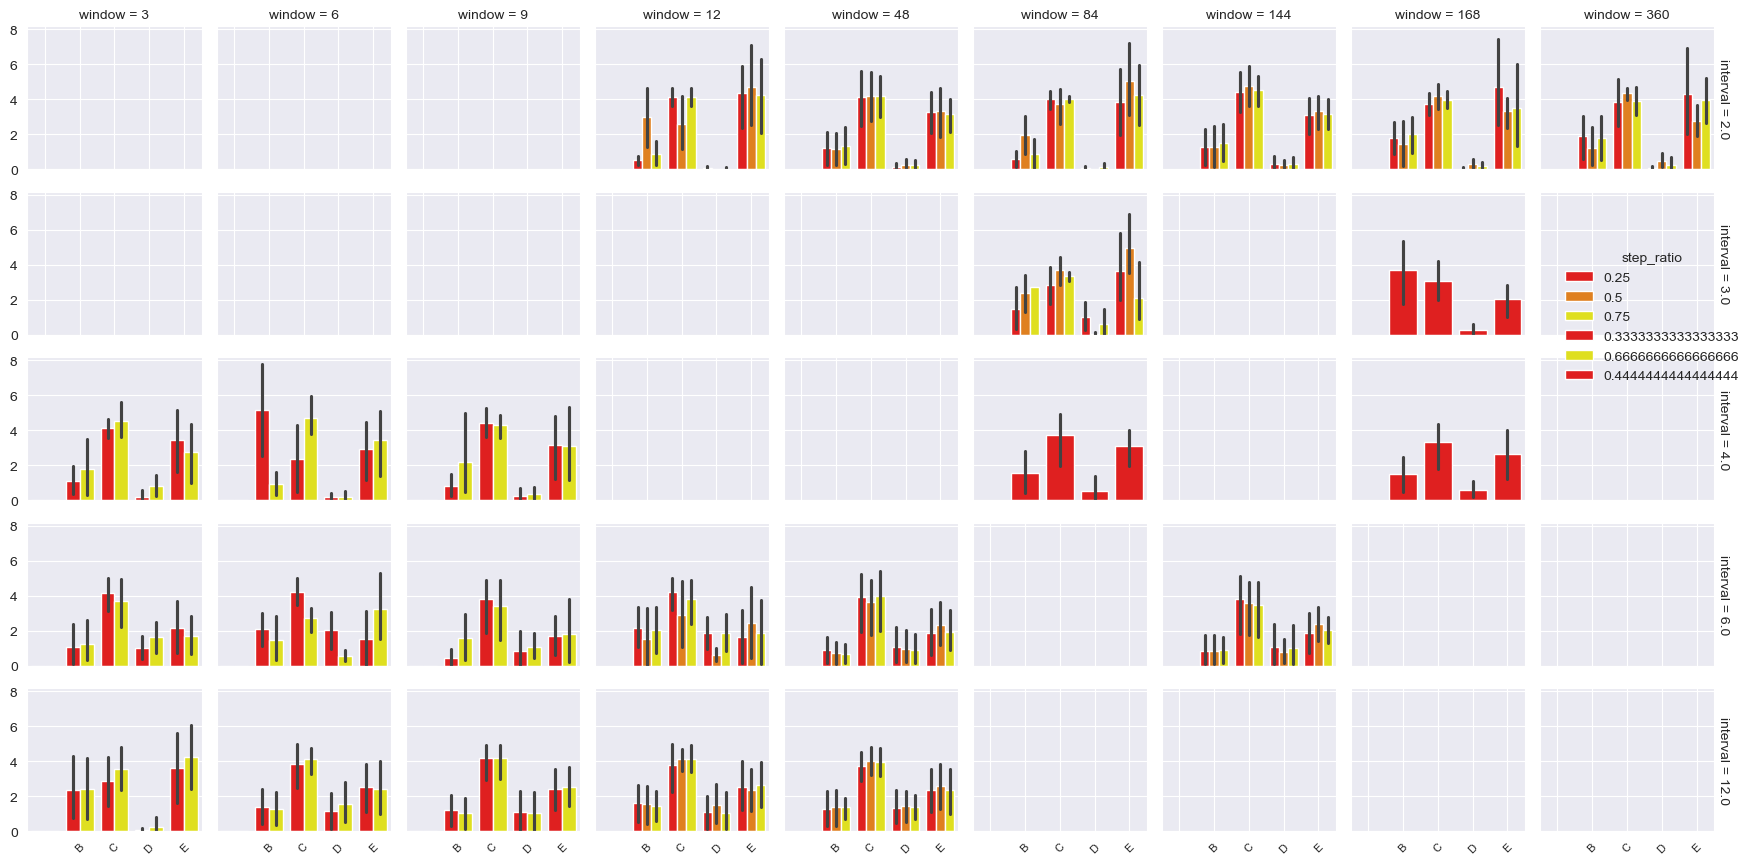

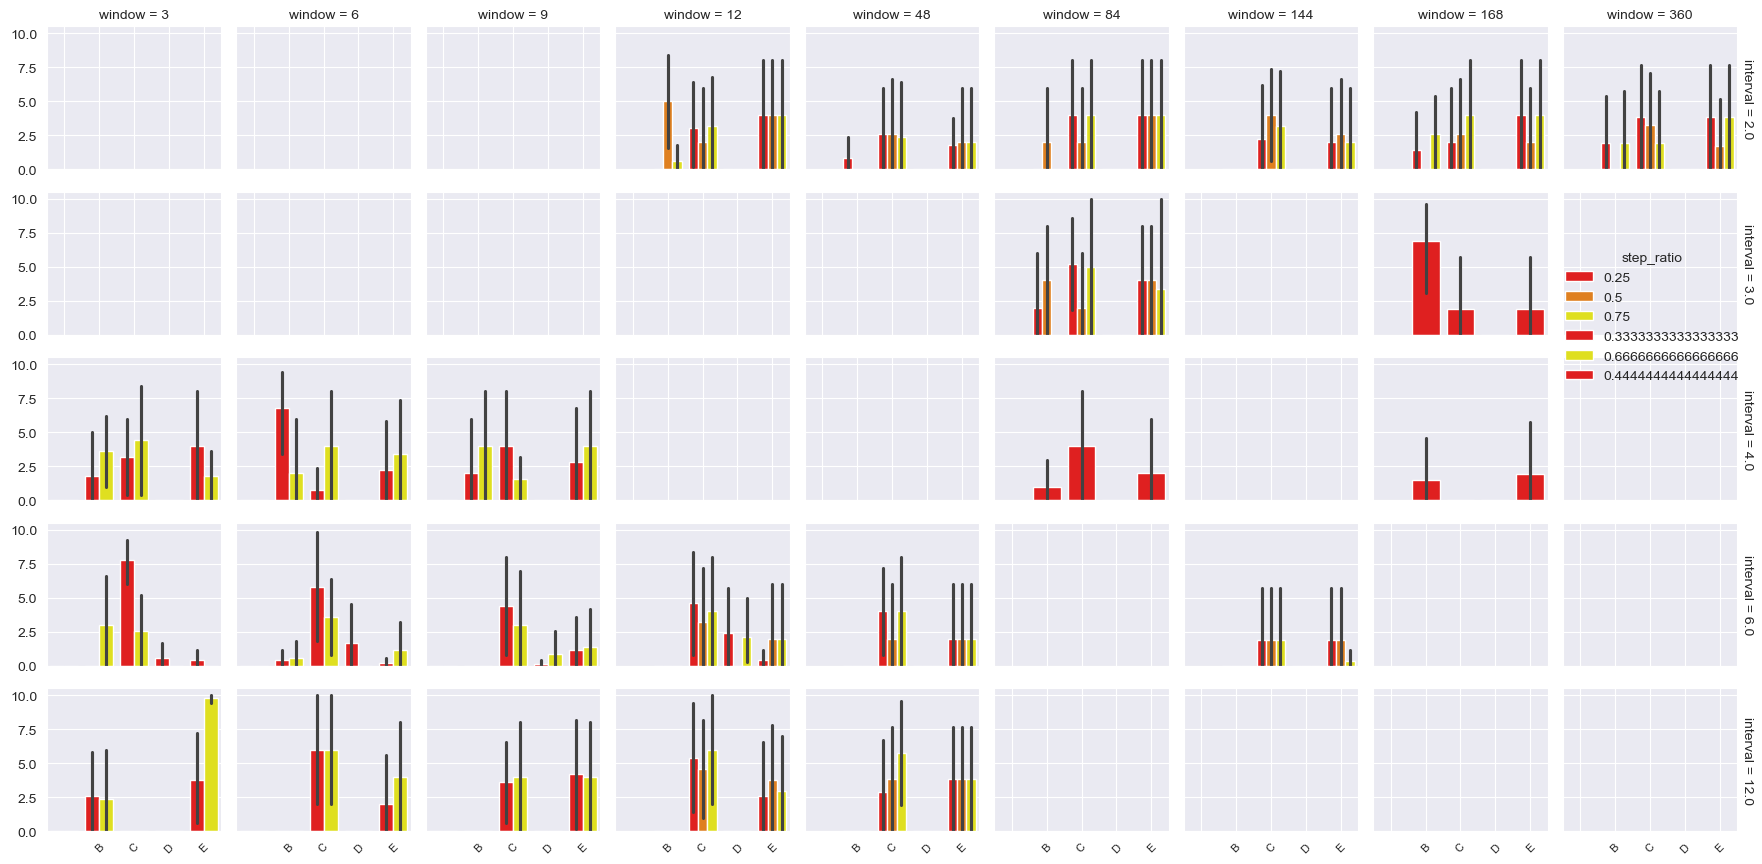

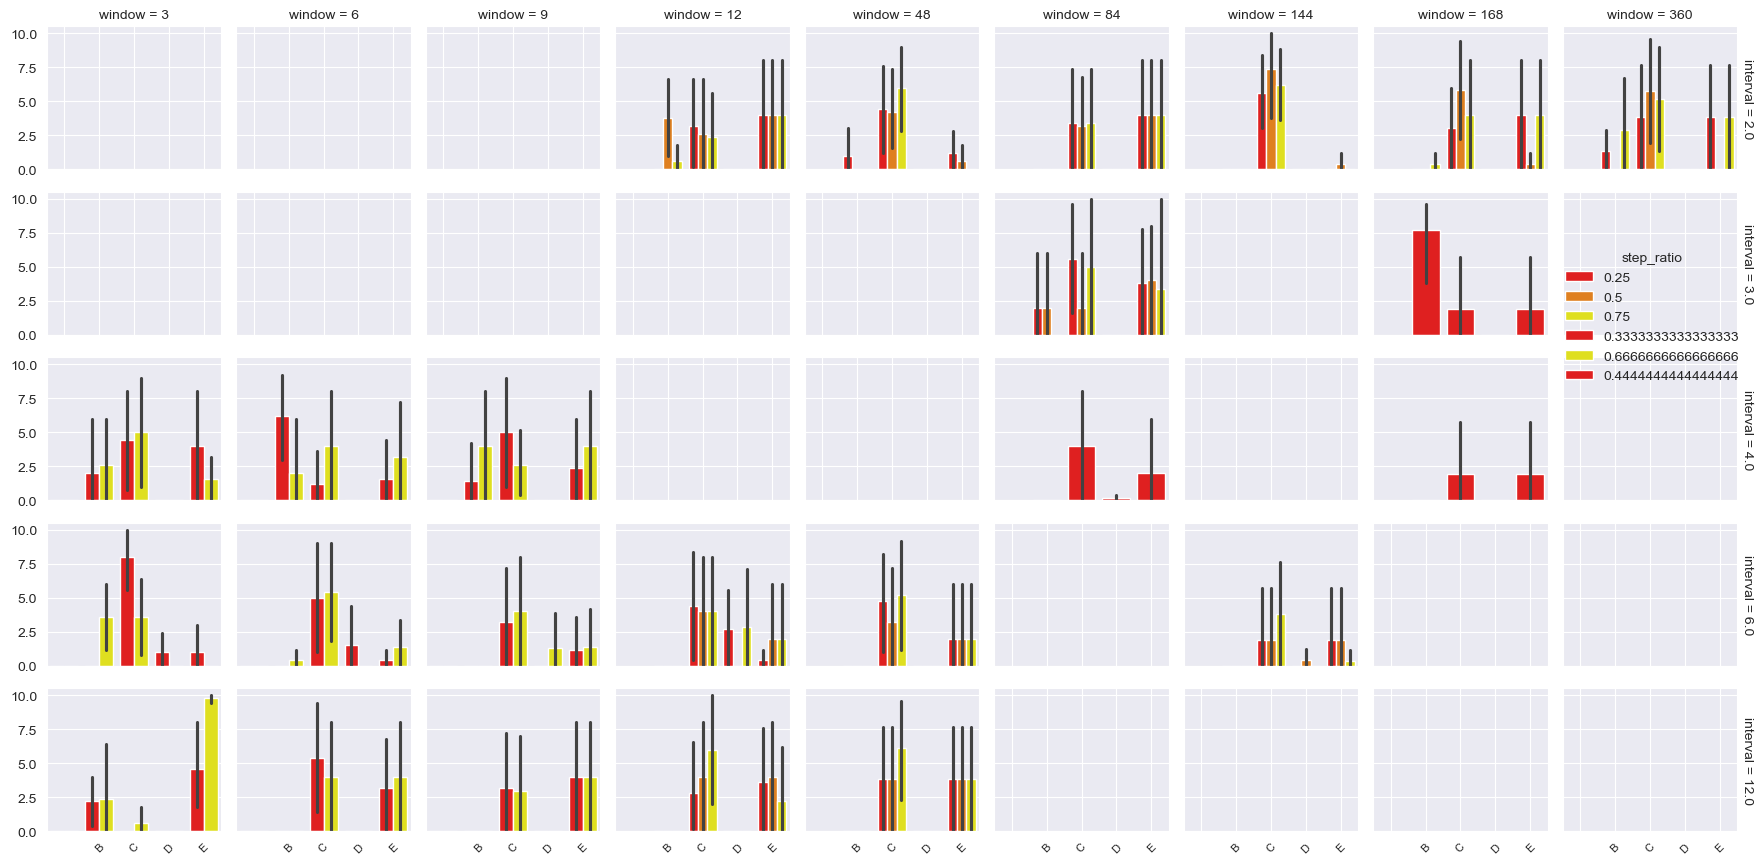

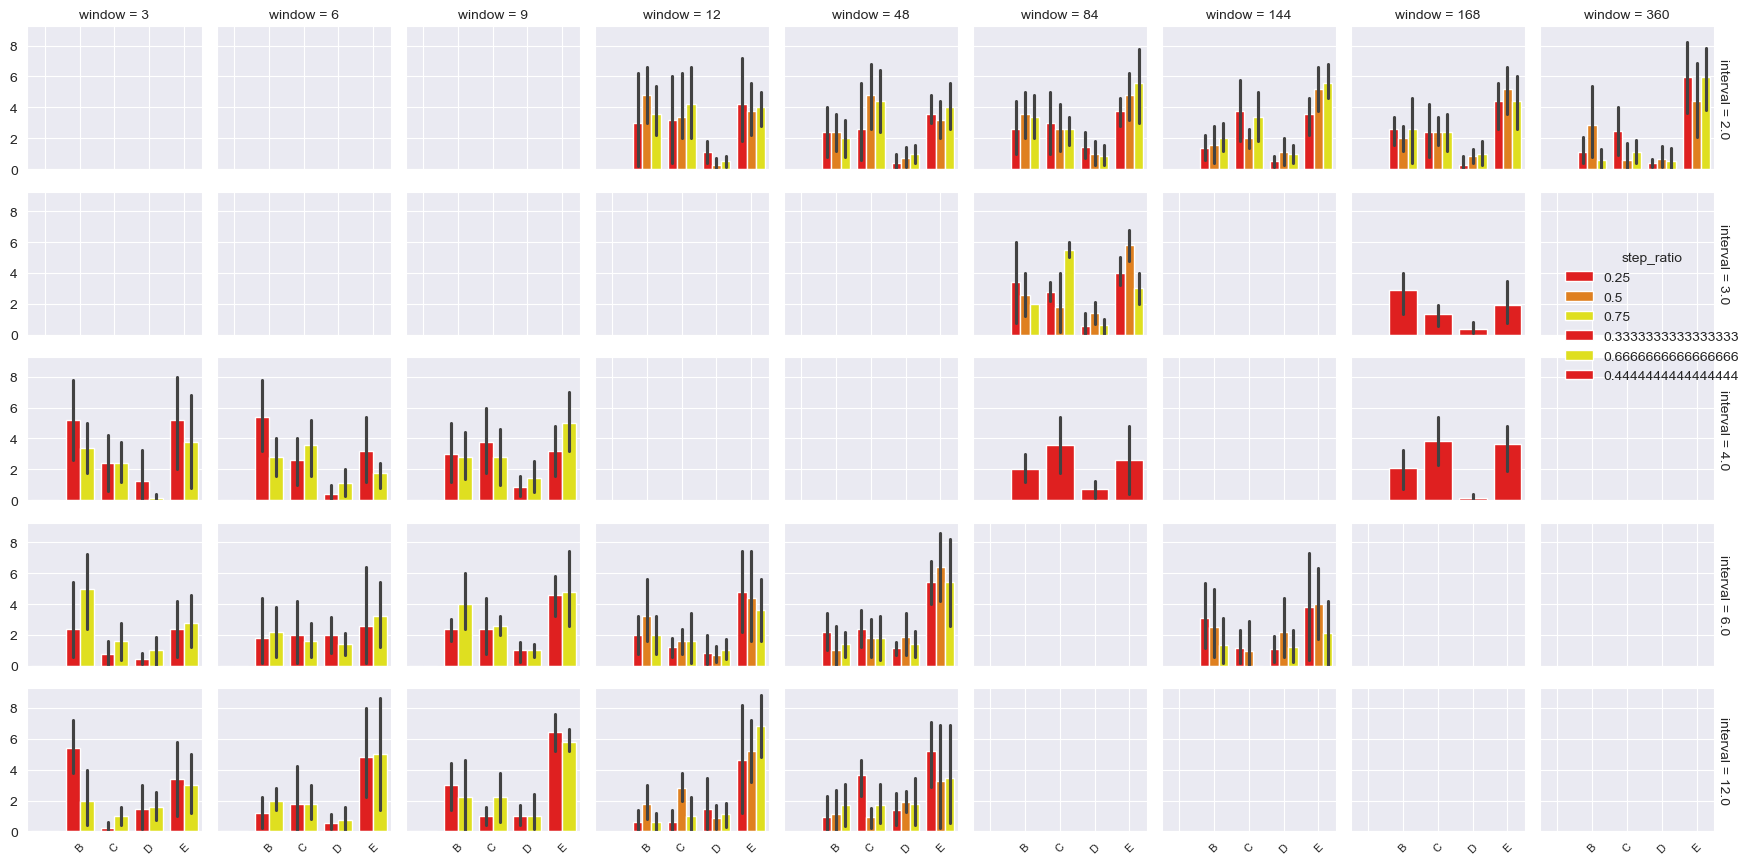

In [31]:
for i, metric in enumerate(['cosine', 'wavelet', 'dft', 'autocorr']):


    qwe = data_exps[i][2]
    qwe[['window', 'step', 'interval']] = qwe['experiment'].str.split('__').str[2].str.split('_', expand = True)
    for col in ['window', 'step', 'interval']:
        qwe[col] = qwe[col].astype(int)
    qwe['step_ratio'] = qwe['step'] / qwe['window']
    qwe['interval'] /= 3600

    qwe['target_district'] = qwe['target_district_node'].str.split('_').str[0]
    qwe['target_initial_state'] = qwe['target_init_final_state'].str.split('_').str[-2]
    qwe['target_final_state'] = qwe['target_init_final_state'].str.split('_').str[-1]

    qwe[['A', 'B', 'C', 'D', 'E']] = qwe['initial_state_mapping'].str.split('_', expand = True)

    qwe['similar_districts'] = qwe.apply(find_similar, axis=1)
    qwe['correct_epochs'] = qwe['total_final_matches'] / 24


    col_var = 'window'
    row_var = 'interval'
    hue_var = 'step_ratio'

    # Define FacetGrid with tighter spacing
    g = sns.FacetGrid(
        qwe,
        col=col_var,
        row=row_var,
        col_order=qwe[col_var].sort_values().unique(),
        row_order=qwe[row_var].sort_values().unique(),
        margin_titles=True,        # Helps use space better
        despine=False,             # Keeps axes for reference
        height=1.75,                # Smaller subplot height
        aspect=1                   # Adjust aspect ratio (width / height)
    )

    # Map barplot with narrower bars
    g.map_dataframe(
        sns.barplot,
        x='similar_districts',
        y='correct_epochs',
        order=qwe['similar_districts'].sort_values().unique(),
        hue=hue_var,
        hue_order=qwe[hue_var].sort_values().unique(),
        width=.8,
        palette='autumn'
    )

    # Reduce spacing between subplots
    g.fig.subplots_adjust(
        hspace=0.2,  # vertical space between rows
        wspace=0.05  # horizontal space between columns
    )

    # Reduce legend size and move to a compact position
    g.add_legend(title=hue_var)
    g._legend.set_bbox_to_anchor((.995, 0.625))  # move legend to side
    g._legend.set_frame_on(False)

    # Optional: Rotate x-ticks and tighten layout
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_fontsize(8)
        ax.set_ylabel('')
        ax.set_xlabel('')


    plt.tight_layout()
    plt.savefig(f'results/imgs/{metric}.pdf')


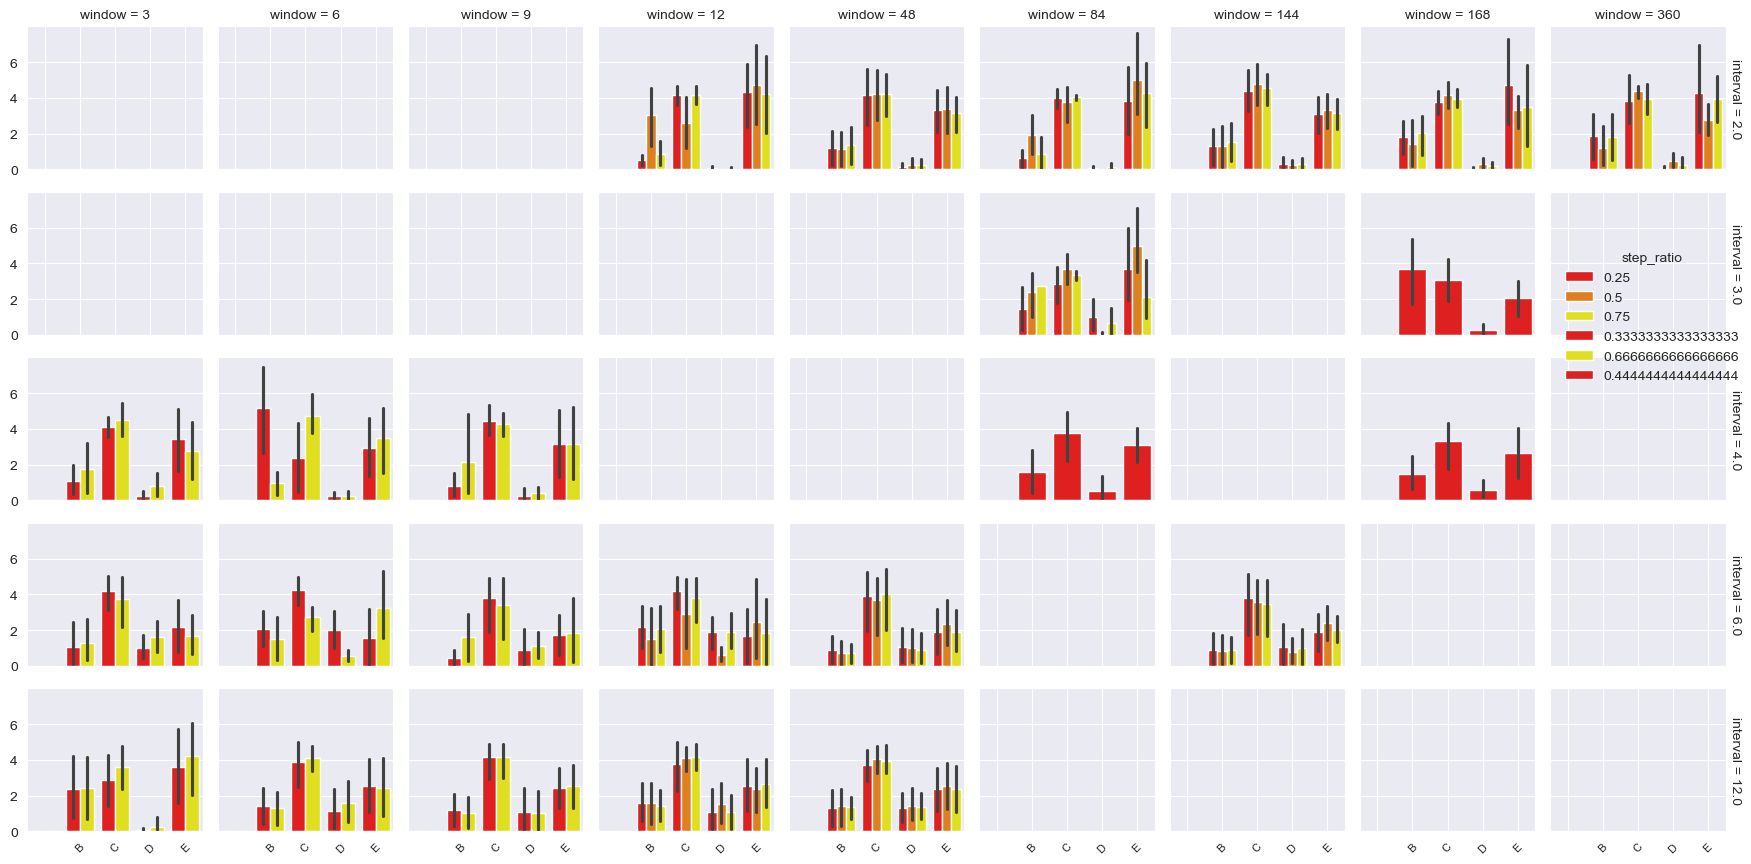

In [28]:
col_var = 'window'
row_var = 'interval'
hue_var = 'step_ratio'

# Define FacetGrid with tighter spacing
g = sns.FacetGrid(
    qwe,
    col=col_var,
    row=row_var,
    col_order=qwe[col_var].sort_values().unique(),
    row_order=qwe[row_var].sort_values().unique(),
    margin_titles=True,        # Helps use space better
    despine=False,             # Keeps axes for reference
    height=1.75,                # Smaller subplot height
    aspect=1                   # Adjust aspect ratio (width / height)
)

# Map barplot with narrower bars
g.map_dataframe(
    sns.barplot,
    x='similar_districts',
    y='correct_epochs',
    order=qwe['similar_districts'].sort_values().unique(),
    hue=hue_var,
    hue_order=qwe[hue_var].sort_values().unique(),
    width=.8,
    palette='autumn'
)

# Reduce spacing between subplots
g.fig.subplots_adjust(
    hspace=0.2,  # vertical space between rows
    wspace=0.05  # horizontal space between columns
)

# Reduce legend size and move to a compact position
g.add_legend(title=hue_var)
g._legend.set_bbox_to_anchor((.995, 0.625))  # move legend to side
g._legend.set_frame_on(False)

# Optional: Rotate x-ticks and tighten layout
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_fontsize(8)
    ax.set_ylabel('')
    ax.set_xlabel('')

plt.savefig('results/imgs/{metric}.pdf')
plt.tight_layout()

In [17]:
data_exps[0][2].loc[0]['experiment'].split('__')[2].split('_')

['12', '3', '43200']

In [59]:
clients = ['District_A', 'District_B', 'District_C', 'District_D', 'District_E']
nodes = ['62', '84', '65', '2', '15']
drifts = [['LL_LM_LH_LL_LL','LL_LH_LM_LL_LL','LL_LL_LL_LM_LH','LL_LL_LL_LH_LM','LL_LH_LL_LL_LM','LL_LL_LM_LH_LL','LL_LL_LH_LM_LL'],
['LM_LL_LH_LL_LL','LH_LL_LM_LL_LL','LL_LL_LL_LM_LH','LL_LL_LL_LH_LM','LH_LL_LL_LL_LM','LL_LL_LM_LH_LL','LL_LL_LH_LM_LL'],
['LM_LH_LL_LL_LL','LH_LM_LL_LL_LL','LL_LL_LL_LM_LH','LL_LL_LL_LH_LM','LH_LL_LL_LL_LM','LL_LM_LL_LH_LL','LL_LH_LL_LM_LL'],
['LM_LH_LL_LL_LL','LH_LM_LL_LL_LL','LL_LL_LM_LL_LH','LL_LL_LH_LL_LM','LH_LL_LL_LL_LM','LL_LM_LH_LL_LL','LL_LH_LM_LL_LL'],
['LM_LH_LL_LL_LL','LH_LM_LL_LL_LL','LL_LL_LM_LH_LL','LL_LL_LH_LM_LL','LH_LL_LL_LM_LL','LL_LM_LH_LL_LL','LL_LH_LM_LL_LL']]


i= 0
for client, node, drift in zip(clients, nodes, drifts):
    print(client, node, drift)
    i+=1
    if i == 10:
        break

District_A 62 ['LL_LM_LH_LL_LL', 'LL_LH_LM_LL_LL', 'LL_LL_LL_LM_LH', 'LL_LL_LL_LH_LM', 'LL_LH_LL_LL_LM', 'LL_LL_LM_LH_LL', 'LL_LL_LH_LM_LL']
District_B 84 ['LM_LL_LH_LL_LL', 'LH_LL_LM_LL_LL', 'LL_LL_LL_LM_LH', 'LL_LL_LL_LH_LM', 'LH_LL_LL_LL_LM', 'LL_LL_LM_LH_LL', 'LL_LL_LH_LM_LL']
District_C 65 ['LM_LH_LL_LL_LL', 'LH_LM_LL_LL_LL', 'LL_LL_LL_LM_LH', 'LL_LL_LL_LH_LM', 'LH_LL_LL_LL_LM', 'LL_LM_LL_LH_LL', 'LL_LH_LL_LM_LL']
District_D 2 ['LM_LH_LL_LL_LL', 'LH_LM_LL_LL_LL', 'LL_LL_LM_LL_LH', 'LL_LL_LH_LL_LM', 'LH_LL_LL_LL_LM', 'LL_LM_LH_LL_LL', 'LL_LH_LM_LL_LL']
District_E 15 ['LM_LH_LL_LL_LL', 'LH_LM_LL_LL_LL', 'LL_LL_LM_LH_LL', 'LL_LL_LH_LM_LL', 'LH_LL_LL_LM_LL', 'LL_LM_LH_LL_LL', 'LL_LH_LM_LL_LL']


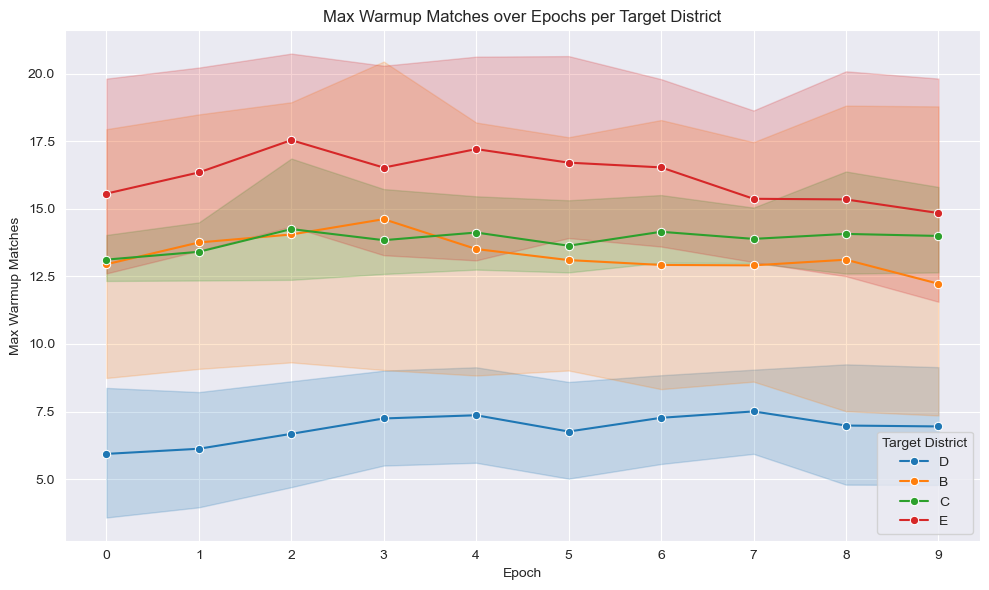

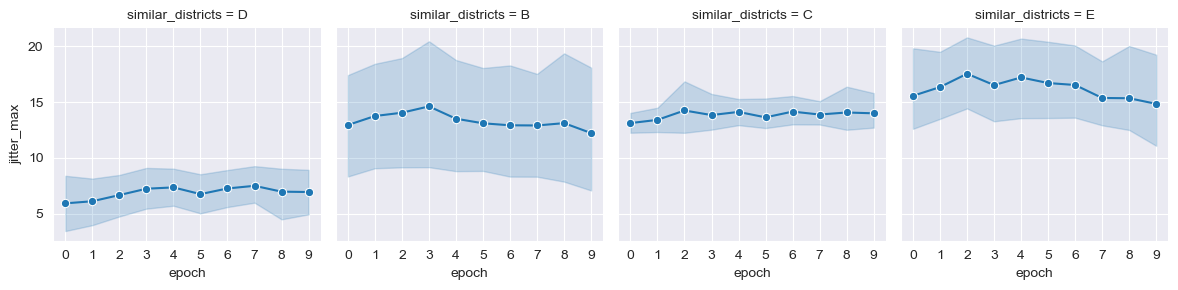

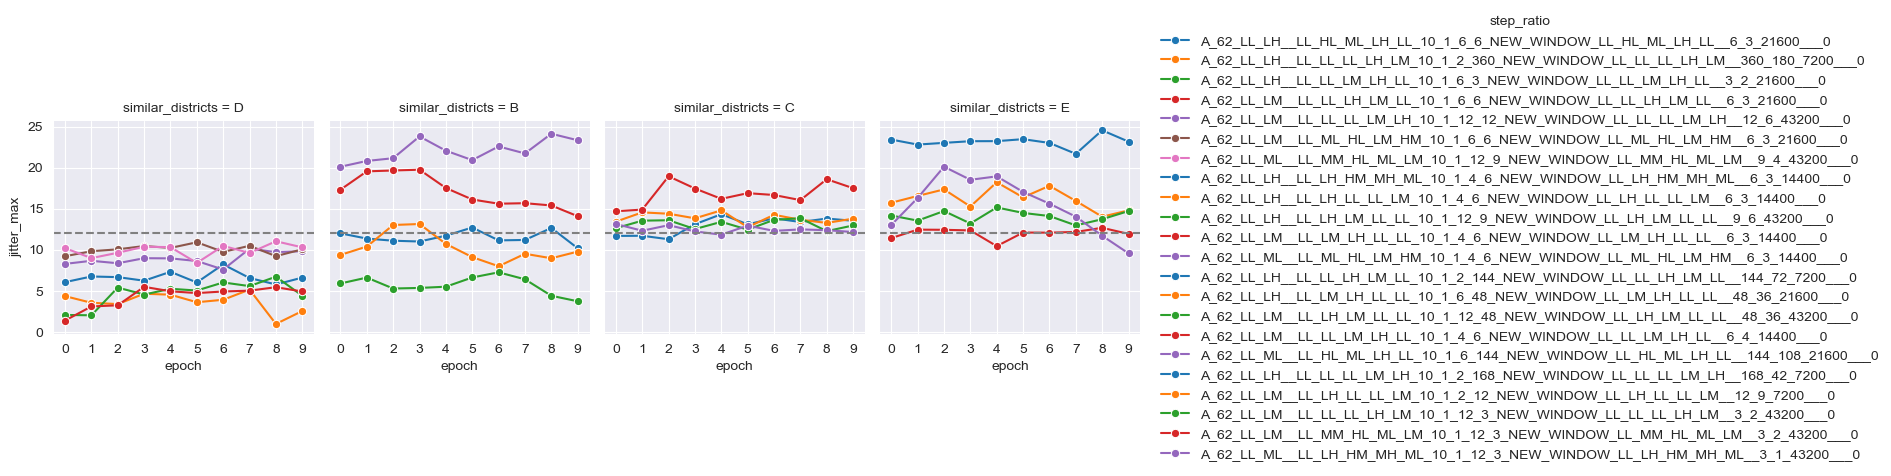

In [39]:
epochs_results_window_cosine, best_results_window_cosine, exp_df_cosine, epoch_results_cosine = compute_results(experiment_id = 'NEW_WINDOW', metrics = ['cosine'])

df_plot_window_cosine = epochs_results_window_cosine[epochs_results_window_cosine['experiment'].isin(best_results_window_cosine['experiment'])].copy()
df_plot_window_cosine['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot_window_cosine))]
df_plot_window_cosine['jitter_max'] = df_plot_window_cosine['max_final_matches'] + df_plot_window_cosine['aux'] 

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot_window_cosine,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot_window_cosine, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot_window_cosine, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )
g.refline(y=12)

g.add_legend(title=hue_var)

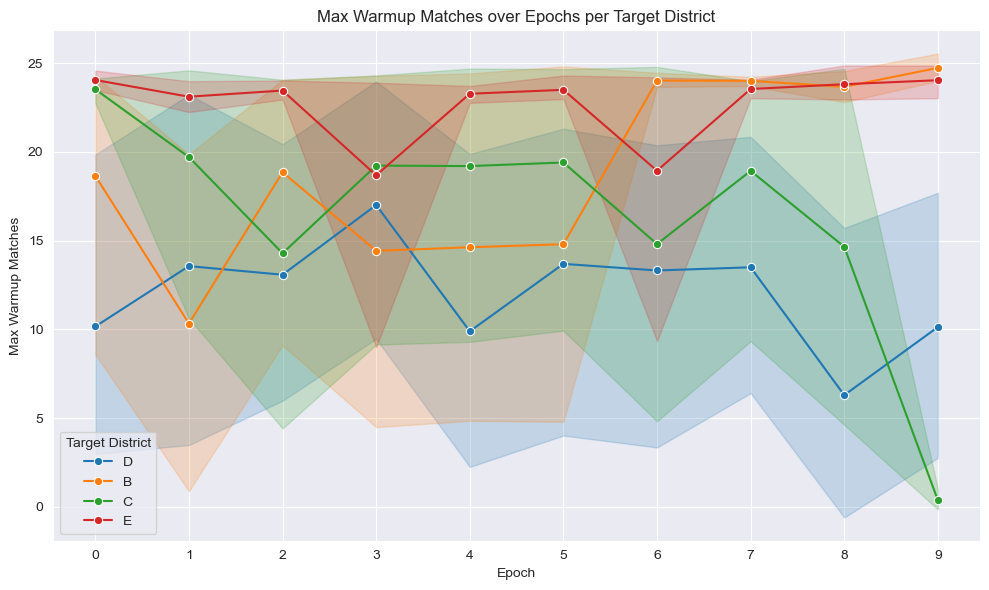

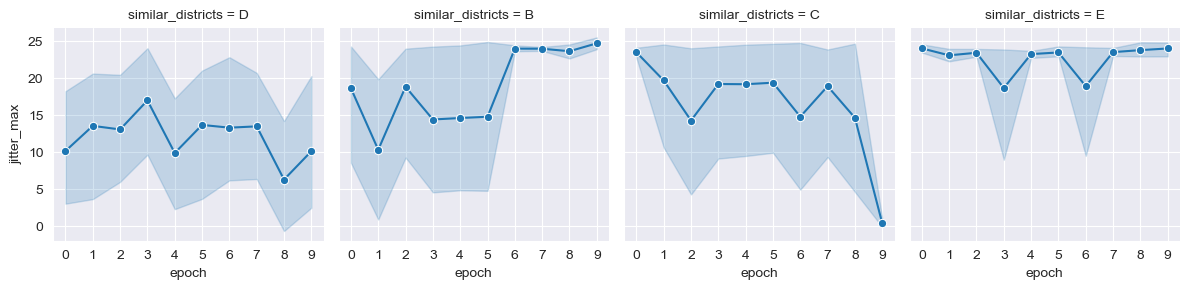

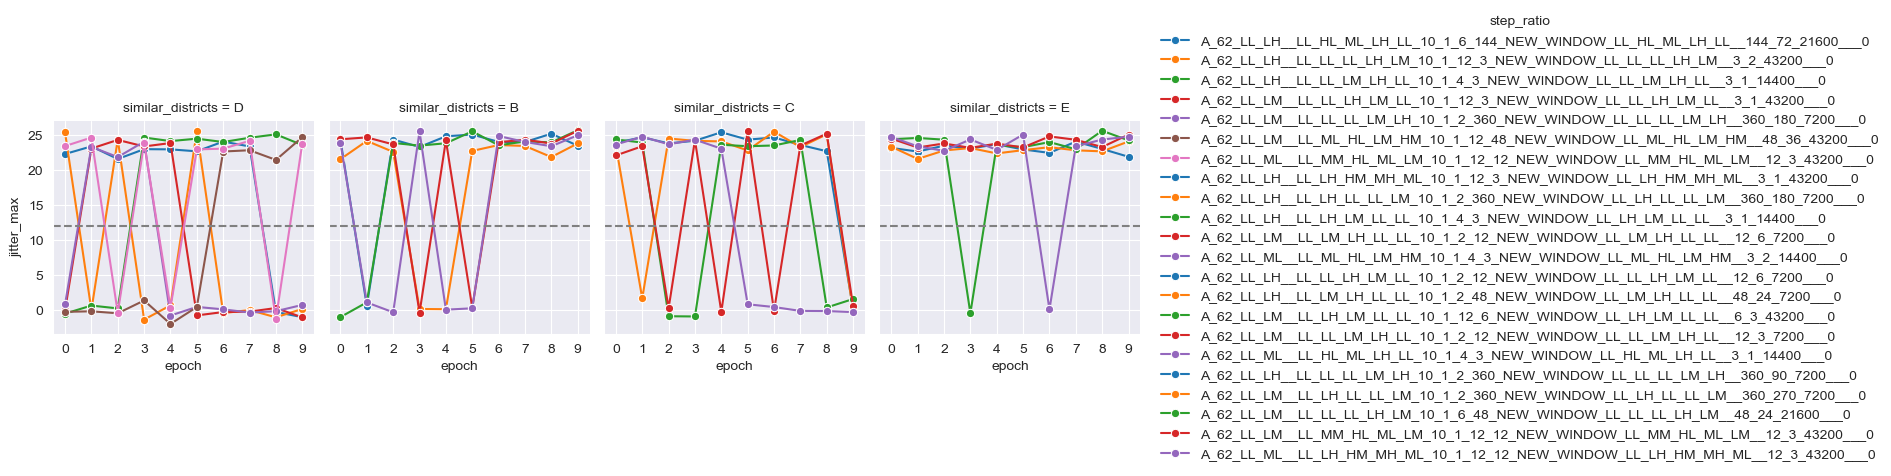

In [40]:
epochs_results_window_autocorr, best_results_window_autocorr, exp_df_autocorr, epoch_results_autocorr = compute_results(experiment_id = 'NEW_WINDOW', metrics = ['autocorr'])

df_plot_window_autocorr = epochs_results_window_autocorr[epochs_results_window_autocorr['experiment'].isin(best_results_window_autocorr['experiment'])].copy()
df_plot_window_autocorr['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot_window_autocorr))]
df_plot_window_autocorr['jitter_max'] = df_plot_window_autocorr['max_final_matches'] + df_plot_window_autocorr['aux']

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot_window_autocorr,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot_window_autocorr, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot_window_autocorr, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )
g.refline(y=12)

g.add_legend(title=hue_var)

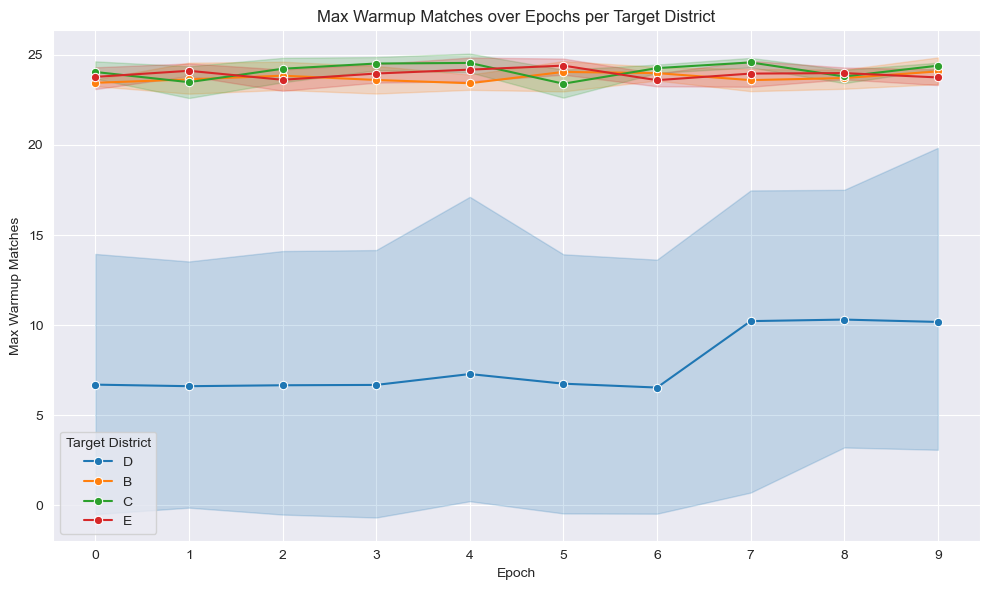

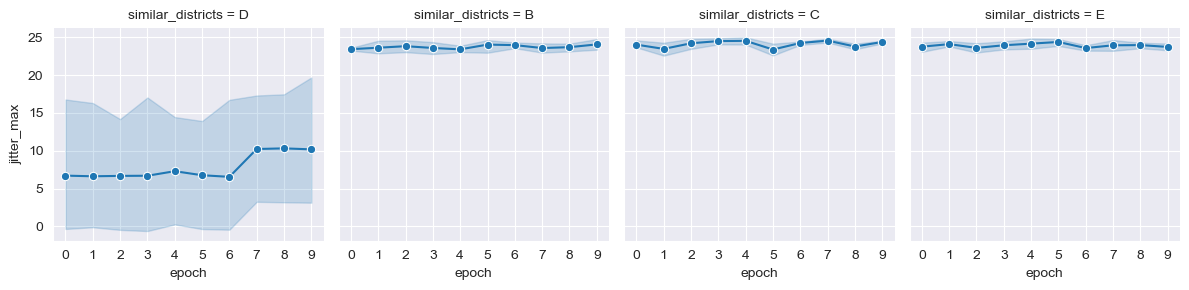

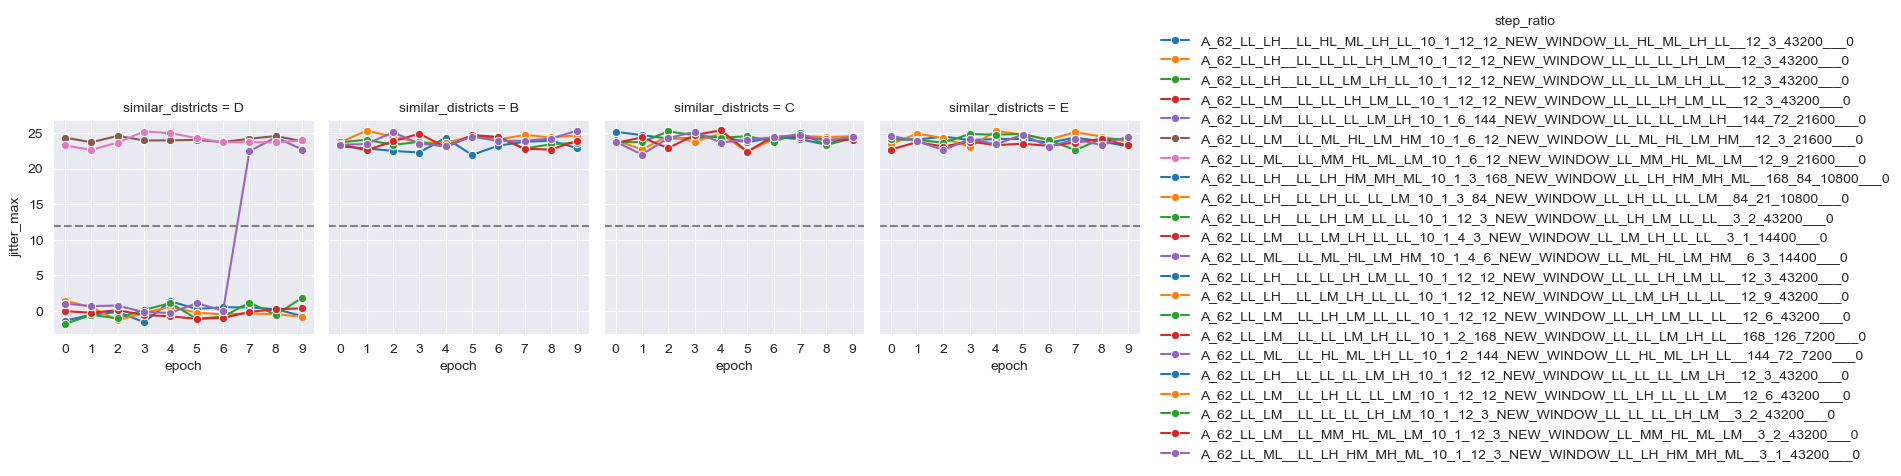

In [41]:
epochs_results_window_dft, best_results_window_dft, exp_df_dft, epoch_results_dft = compute_results(experiment_id = 'NEW_WINDOW', metrics = ['dft'])

df_plot_window_dft = epochs_results_window_dft[epochs_results_window_dft['experiment'].isin(best_results_window_dft['experiment'])].copy()
df_plot_window_dft['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot_window_dft))]
df_plot_window_dft['jitter_max'] = df_plot_window_dft['max_final_matches'] + df_plot_window_dft['aux']

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot_window_dft,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot_window_dft, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot_window_dft, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )
g.refline(y=12)

g.add_legend(title=hue_var)

In [11]:
df_dft = epochs_results_window_dft[epochs_results_window_dft['total_final_matches'] > 20].copy()
df_dft_agg = df_dft.groupby(['experiment', 'exp_id', 'similar_districts']).agg({'correct_epochs' : 'count'}).reset_index()
df_dft_agg[['window', 'step', 'interval']] = df_dft_agg['exp_id'].str.split('__').str[0].str.split('_', expand = True).astype(int)

df_dft_agg['step_ratio'] = df_dft_agg['step'] / df_dft_agg['window']

df_dft_agg_filter = df_dft_agg[df_dft_agg['correct_epochs'] >= 7].drop(columns = ['experiment'])


df_dft_agg_filter

,exp_id,similar_districts,correct_epochs,window,step,interval,step_ratio
1,12_6_7200__0,B,8,12,6,7200,0.500000
6,168_84_10800__0,B,10,168,84,10800,0.500000
12,360_270_7200__0,B,10,360,270,7200,0.750000
14,168_84_10800__0,B,10,168,84,10800,0.500000
15,84_21_10800__0,B,10,84,21,10800,0.250000
...,...,...,...,...,...,...,...
273,3_2_14400__0,B,9,3,2,14400,0.666667
274,6_3_14400__0,B,10,6,3,14400,0.500000
275,9_6_14400__0,B,10,9,6,14400,0.666667
276,12_3_21600__0,D,9,12,3,21600,0.250000


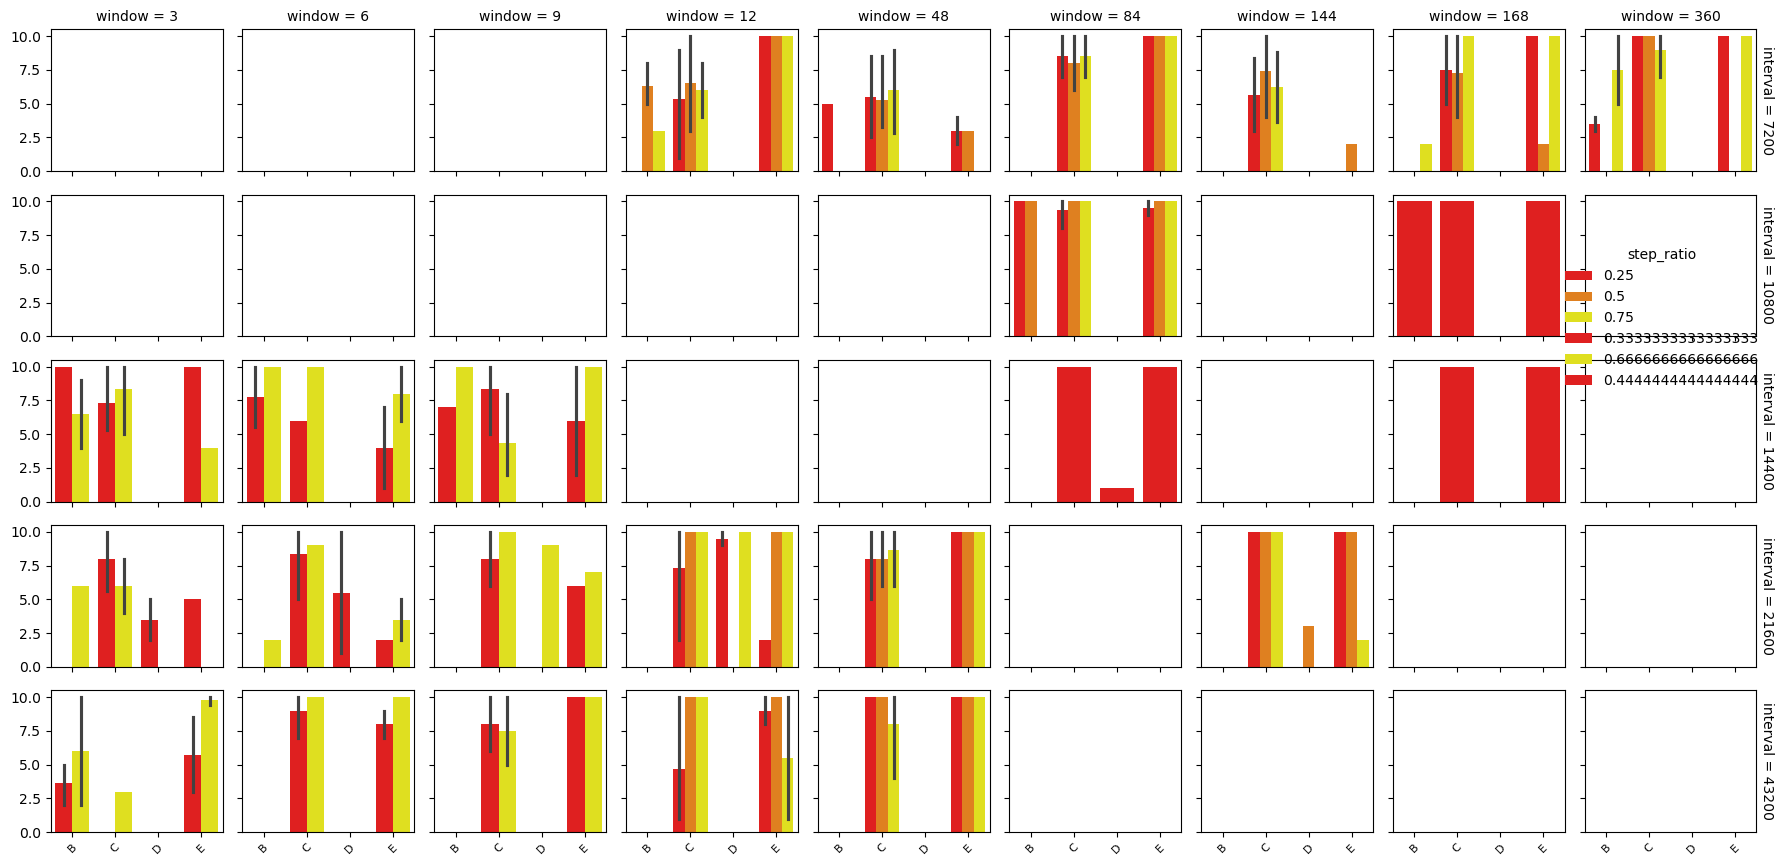

In [25]:
col_var = 'window'
row_var = 'interval'
hue_var = 'step_ratio'

# Define FacetGrid with tighter spacing
g = sns.FacetGrid(
    df_dft_agg,
    col=col_var,
    row=row_var,
    col_order=df_dft_agg[col_var].sort_values().unique(),
    row_order=df_dft_agg[row_var].sort_values().unique(),
    margin_titles=True,        # Helps use space better
    despine=False,             # Keeps axes for reference
    height=1.75,                # Smaller subplot height
    aspect=1                   # Adjust aspect ratio (width / height)
)

# Map barplot with narrower bars
g.map_dataframe(
    sns.barplot,
    x='similar_districts',
    y='correct_epochs',
    order=df_dft_agg['similar_districts'].sort_values().unique(),
    hue=hue_var,
    hue_order=df_dft_agg[hue_var].sort_values().unique(),
    width=.8,                
    palette='autumn'
)

# Reduce spacing between subplots
g.fig.subplots_adjust(
    hspace=0.2,  # vertical space between rows
    wspace=0.05  # horizontal space between columns
)

# Reduce legend size and move to a compact position
g.add_legend(title=hue_var)
g._legend.set_bbox_to_anchor((.995, 0.625))  # move legend to side
g._legend.set_frame_on(False)

# Optional: Rotate x-ticks and tighten layout
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_fontsize(8)
    ax.set_ylabel('')
    ax.set_xlabel('')

plt.tight_layout()

In [71]:
exp_name = 'A_62_LL_LH__LL_LH_LL_LL_LM_10_1_3_84_NEW_WINDOW_LL_LH_LL_LL_LM__84_21_10800___0'
metrics = ['dft']

proto = pd.read_parquet(f'results/{exp_name}/Baseline_proto.parquet')

results_tgt = proto[proto['client_1'].str.contains(f'_A_')].drop(columns=['client_1'])

# Compute rank based on the metrics
results_tgt['test_metric'] = results_tgt[metrics[0]]
if len(metrics) != 1:
    for metric in metrics[1:]:
        results_tgt['test_metric'] += results_tgt[metric] 
results_tgt['rank'] = results_tgt.groupby(['epoch', 'label'])['test_metric'].rank(method='dense', ascending=True)

# Analyse the results over experiments
exp_result = analyze_experiment(results_df = results_tgt, results_id = exp_name)

epoch_results = []
case_epochs = []
for epoch in results_tgt['epoch'].unique():
    data_epoch = results_tgt[results_tgt['epoch'] == epoch]
    result = analyze_experiment(results_df = data_epoch, results_id = exp_name)
    result['epoch'] = epoch

    case_epochs.append(result)
    
    result_df = pd.DataFrame(result, index = [0])
    best_epochs = compute_best_cases(result_df)
    epoch_results.append(best_epochs.copy())

exp_result = pd.DataFrame(case_epochs)
best_result = compute_best_cases(exp_result)

exp_epochs = pd.concat(epoch_results)
exp_epochs

,experiment,total_final_matches,total_warmup_matches,max_final_matches,max_warmup_matches,epoch,exp_id,correct_epochs,target_district,target_initial_state,target_final_state,A,B,C,D,E,similar_districts
0,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_3_84_NEW_WINDO...,24,21,24,21,0,84_21_10800__0,1.0,A,LL,LH,LL,LH,LL,LL,LM,B
0,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_3_84_NEW_WINDO...,24,21,24,21,1,84_21_10800__0,1.0,A,LL,LH,LL,LH,LL,LL,LM,B
0,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_3_84_NEW_WINDO...,24,21,24,21,2,84_21_10800__0,1.0,A,LL,LH,LL,LH,LL,LL,LM,B
0,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_3_84_NEW_WINDO...,24,21,24,21,3,84_21_10800__0,1.0,A,LL,LH,LL,LH,LL,LL,LM,B
0,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_3_84_NEW_WINDO...,24,21,24,21,4,84_21_10800__0,1.0,A,LL,LH,LL,LH,LL,LL,LM,B
0,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_3_84_NEW_WINDO...,24,21,24,21,5,84_21_10800__0,1.0,A,LL,LH,LL,LH,LL,LL,LM,B
0,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_3_84_NEW_WINDO...,24,21,24,21,6,84_21_10800__0,1.0,A,LL,LH,LL,LH,LL,LL,LM,B
0,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_3_84_NEW_WINDO...,24,21,24,21,7,84_21_10800__0,1.0,A,LL,LH,LL,LH,LL,LL,LM,B
0,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_3_84_NEW_WINDO...,24,21,24,21,8,84_21_10800__0,1.0,A,LL,LH,LL,LH,LL,LL,LM,B
0,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_3_84_NEW_WINDO...,24,21,24,21,9,84_21_10800__0,1.0,A,LL,LH,LL,LH,LL,LL,LM,B


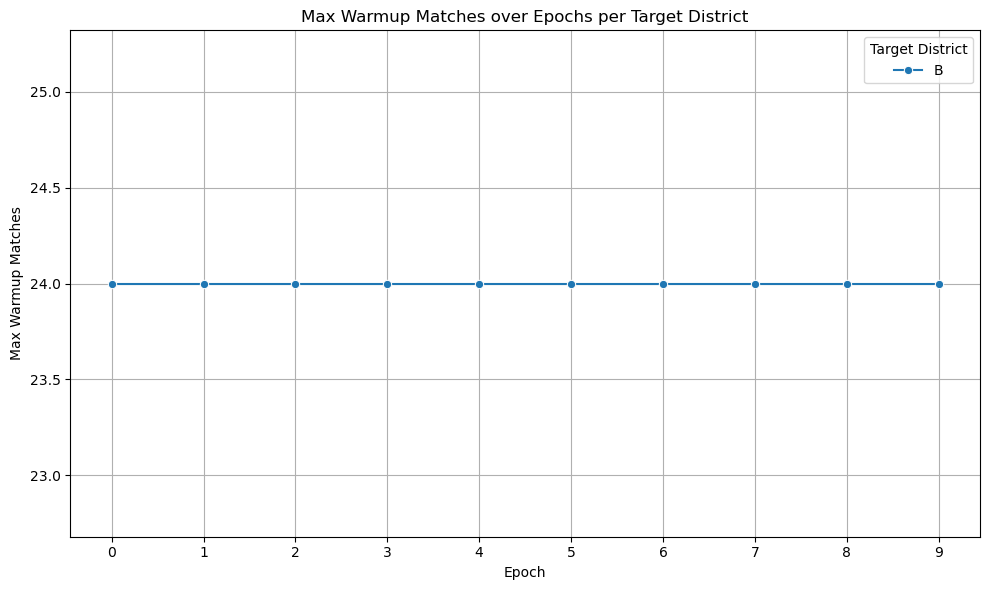

In [73]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=exp_epochs,
    x='epoch',
    y='total_final_matches',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
epoch_tgt = results_tgt[results_tgt['epoch'] == '0'].copy()
epoch_tgt



,epoch,label,client_2,cosine,manhattan,wavelet,dft,autocorr,test_metric,rank
0,0,0,District_B__proto,0.023683,0.785894,2.482610,2.584661,0.120632,2.584661,1.0
1,0,0,District_C__proto,0.026496,0.794344,2.761772,2.769792,0.121028,2.769792,4.0
2,0,0,District_D__proto,0.029209,0.879361,2.636819,2.698188,0.127506,2.698188,3.0
3,0,0,District_E__proto,0.025194,0.807668,2.623269,2.676226,0.118858,2.676226,2.0
20,0,1,District_B__proto,0.025367,0.813650,2.482610,2.584661,0.120632,2.584661,1.0
...,...,...,...,...,...,...,...,...,...,...
443,0,22,District_E__proto,0.005195,0.380654,2.623269,2.676226,0.118858,2.676226,2.0
460,0,23,District_B__proto,0.008682,0.513790,2.482610,2.584661,0.120632,2.584661,1.0
461,0,23,District_C__proto,0.011286,0.586815,2.761772,2.769792,0.121028,2.769792,4.0
462,0,23,District_D__proto,0.009624,0.567158,2.636819,2.698188,0.127506,2.698188,3.0


In [93]:
import pickle

exp_name = 'A_62_LL_LH__LL_LH_LL_LL_LM_10_1_3_84_NEW_WINDOW_LL_LH_LL_LL_LM__84_21_10800___0'
file_path = f'results/{exp_name}/results.pkl'

with open(file_path, 'rb') as f:
    data = pickle.load(f)

args = data['Baseline']['args']

In [103]:
import os
import pickle
import warnings

import pandas as pd
from tqdm import tqdm
from collections import defaultdict
from datasets import get_private_dataset
from utils.Server import local_evaluate
from utils.Toolbox_analysis import create_latent_df, process_latent_df
from utils.Toolbox_postprocessing import proto_analysis, distributions_analysis
from utils.Toolbox_visualization import load_and_scale_data, combine_latents, plot_latent_heatmap, plot_time_series_and_latents
from utils.Toolbox_visualization import plot_proto_similar, plot_distribution_similar

import warnings
warnings.filterwarnings('ignore')

agg_int = int(args.interval_agg / 3600)
results_id = f'{args.experiment_id}_{args.communication_epoch}_{args.local_epoch}_{agg_int}_{args.window_size}_{args.extra_coments}'
results_dir = f"results/{results_id}"

results_path = f"{results_dir}/results.pkl"
with open(results_path, 'rb') as f:
    results = pickle.load(f)


args = results['Baseline']['args']
label_clients = [
    'District_A', 'District_B', 'District_C', 'District_D', 'District_E',
    'District_2A', 'District_2B', 'District_2C'
]

priv_dataset = get_private_dataset(args)
backbones_list = priv_dataset.get_backbone(
    parti_num=args.parti_num,
    names_list=None,
    n_series=args.input_size
)

train_DL = priv_dataset.get_data_loaders()
base_index = train_DL[0]['X_index']
latent_dfs = {}
scenarios = ['Baseline']
        

all_latents = defaultdict(list)
all_protos = defaultdict(list)
all_dists = defaultdict(list)
all_pca = defaultdict(list)
all_umap = defaultdict(list)

for scenario in scenarios:
    global_model_history = results[scenario]['model']['global_weights_history']
    
    iterator = tqdm(range(args.communication_epoch))
    for epoch in iterator:
        aux_latents = []
        state_dict = global_model_history[epoch]
        for net in backbones_list:
            net.load_state_dict(state_dict)

        latent_spaces = local_evaluate(model=backbones_list,
                                       train_dl=train_DL,
                                       private_dataset=priv_dataset,
                                       group_detections=False,
                                       detect_anomalies=False)

        for i, client in enumerate(latent_spaces):
            client_lat = create_latent_df(
                X_index=base_index,
                x_lat=client,
                label=f"{label_clients[i]}__{epoch}",
                is_unix=True
            )
            aux_latents.append(client_lat)

        data_latent = pd.concat(aux_latents)
        data_latent[['client_id', 'epoch']] = data_latent['label'].str.split('__', expand=True)

        # Extract year and month
        years = data_latent['timestamp'].dt.year
        months = data_latent['timestamp'].dt.month

        # Compute base year from the minimum timestamp
        base_year = data_latent['timestamp'].min().year

        # Continuous month index
        data_latent['label'] = (years - base_year) * 12 + (months - 1)

        id_cols = ['client_id', 'label', 'epoch']
        feat_cols = [col for col in data_latent.columns if 'x_' in col]
        aux_agg = data_latent[id_cols + feat_cols]
        aux_agg = aux_agg.groupby(id_cols).mean().reset_index()
        aux_agg = aux_agg.sort_values(by=['epoch', 'label', 'client_id']).reset_index(drop=True)
        aux_agg['client_id'] += '__proto'

        tag = f"{scenario}_{epoch}"
        df_exp_proto = proto_analysis(data_latent=aux_agg, normalize=False)
        aux_df = df_exp_proto.copy()
        aux_df.columns = ['epoch', 'label', 'client_2', 'client_1', 'cosine', 'manhattan', 'wavelet', 'dft', 'autocorr']
        
        df_exp_proto = pd.concat([df_exp_proto, aux_df[df_exp_proto.columns.tolist()]])
        df_exp_proto = df_exp_proto.sort_values(by=['epoch', 'label', 'client_1', 'client_2']).reset_index(drop=True)
        # df_exp_proto['id'] = tag
        
        # df_exp_latent = distributions_analysis(data_distribution=data_latent[id_cols + feat_cols],
        #                                        target_client=args.tgt_district, epoch = epoch, normalize=True)
        # df_exp_latent['id'] = tag

        merged_latent = pd.concat([data_latent[['timestamp'] + id_cols + feat_cols], aux_agg])
        merged_latent = merged_latent.reset_index(drop=True)

        if args.generate_viz:
            df_latent, df_pca_scaled, df_umap_scaled = process_latent_df(
                df_latent=merged_latent,
                umap_neighbors=35,
                umap_min_dist=0.85,
                reduce_raw=False,
                id_cols=['timestamp'] + id_cols,
                return_scaled=False
            )
            # df_latent['id'] = tag
            df_pca_scaled['method'] = 'pca'
            df_umap_scaled['method'] = 'umap'

            all_latents[scenario].append(df_latent)
            all_pca[scenario].append(df_pca_scaled)
            all_umap[scenario].append(df_umap_scaled)
        else:
            # merged_latent['id'] = tag
            all_latents[scenario].append(merged_latent)

        all_protos[scenario].append(df_exp_proto)
        # all_dists[scenario].append(df_exp_latent)


for scenario in scenarios:
    new_latent = pd.concat(all_latents[scenario], ignore_index=True)
    new_proto = pd.concat(all_protos[scenario], ignore_index=True)

  0%|          | 0/10 [00:00<?, ?it/s]C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
 10%|█         | 1/10 [00:12<01:52, 12.47s/it]C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
 20%|██        | 2/10 [00:15<00:56,  7.05s/it]C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
 30%|███       | 3/10 [00:19<00:37,  5.39s/it]C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.

In [157]:
from sklearn.metrics.pairwise import cosine_distances

def client_self_cosine_drift(data_latent):
    features = [col for col in data_latent.columns if col.startswith('x_')]
    results = []

    for client_id, group in data_latent.groupby('client_id'):
        group_sorted = group.sort_values('label')  # Ensure chronological order
        vectors = group_sorted[features].values
        labels = group_sorted['label'].values

        if len(vectors) < 2:
            continue  # Skip clients with only one label

        # First and last vectors
        first_vector = vectors[0].reshape(1, -1)
        last_vector = vectors[-1].reshape(1, -1)

        # 1. Distance of last label to all previous labels
        for i in range(len(vectors) - 1):
            res = {
                'client_id': client_id,
                'label': labels[i],
                'compared_to': labels[-1],
                'drift_type': 'last_vs_earlier',
                'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), last_vector)[0][0],
            }
            results.append(res)

        # 2. Distance of first label to all later labels
        for i in range(1, len(vectors)):
            res = {
                'client_id': client_id,
                'label': labels[i],
                'compared_to': labels[0],
                'drift_type': 'first_vs_later',
                'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), first_vector)[0][0],
            }
            results.append(res)
            
        # 3. Rolling (Consecutive)
        for i in range(len(vectors) - 1):
            results.append({
                'client_id': client_id,
                'label': labels[i],
                'compared_to': labels[i + 1],
                'drift_type': 'rolling',
                'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), vectors[i + 1].reshape(1, -1))[0][0],
            })
            
    return pd.DataFrame(results)

def plot_cosine_drift(df_drift):
    # Filter labels <11 or >13
    df_plot = df_drift[(df_drift['label'] < 11) | (df_drift['label'] > 13)].copy()

    # Create new column for FacetGrid row
    df_plot['label_range'] = df_plot['label'].apply(lambda x: '<11' if x < 11 else '>13')

    # Plot using seaborn FacetGrid
    g = sns.FacetGrid(
        df_plot,
        row='label_range',
        col='drift_type',
        hue='client_id',
        margin_titles=True,
        sharey=False,
        sharex=True,
        height=3,
        aspect=1
    )

    g.map_dataframe(sns.lineplot, x='label', y='cosine_distance')

    g.add_legend()
    g.set_axis_labels("Label", "Cosine Distance")
    g.set_titles(col_template="{col_name}", row_template="Label {row_name}")
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle("Client Self-Cosine Drift Over Labels", fontsize=16)

    plt.show()



EXPERIMENT A_62_:


100%|██████████| 15/15 [01:23<00:00,  5.56s/it]


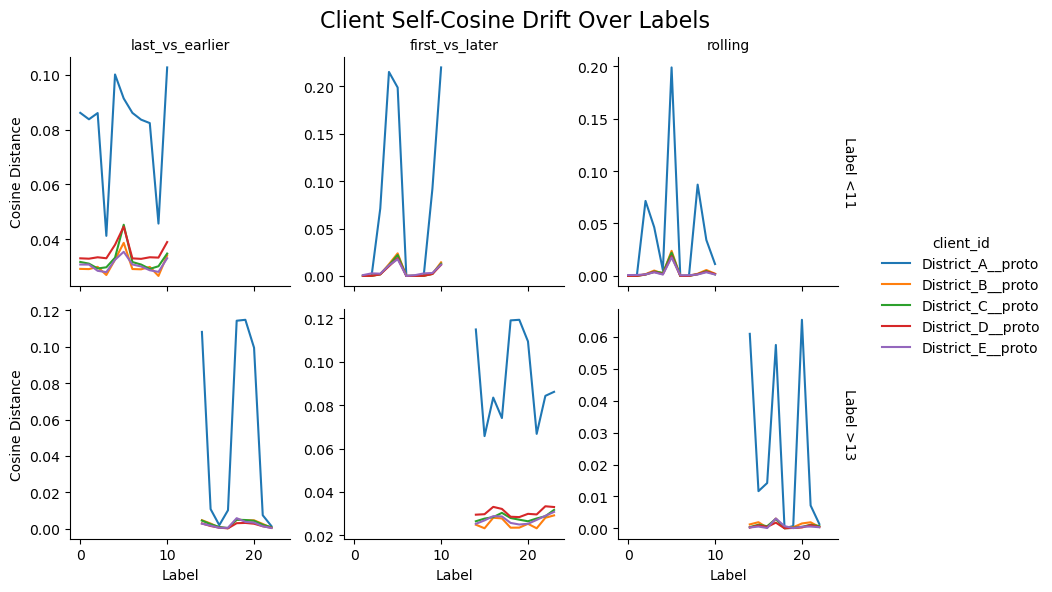



EXPERIMENT B_84_:


100%|██████████| 15/15 [01:37<00:00,  6.53s/it]


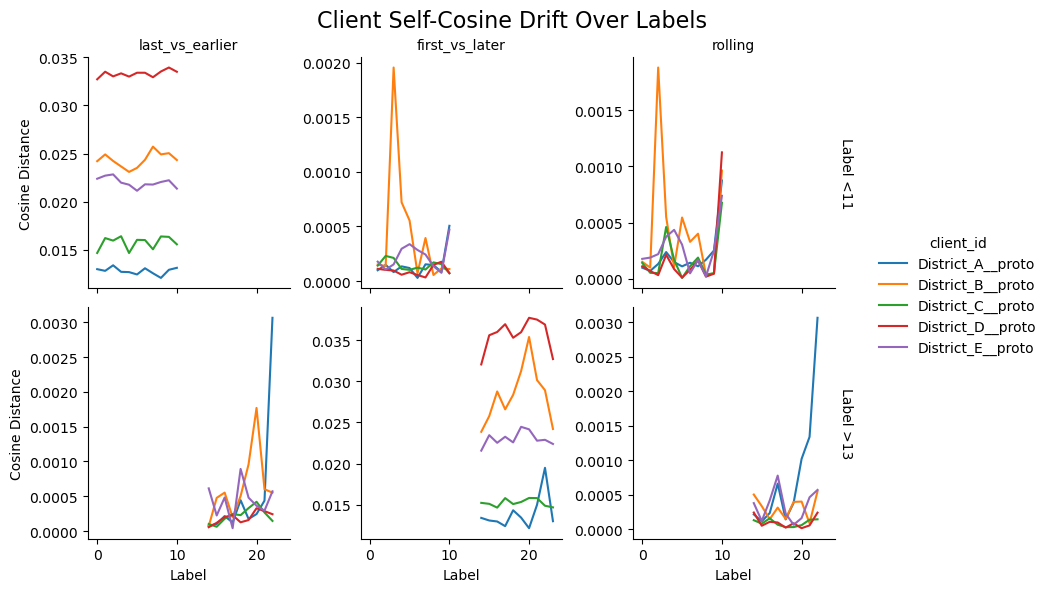



EXPERIMENT C_65_:


100%|██████████| 15/15 [01:22<00:00,  5.48s/it]


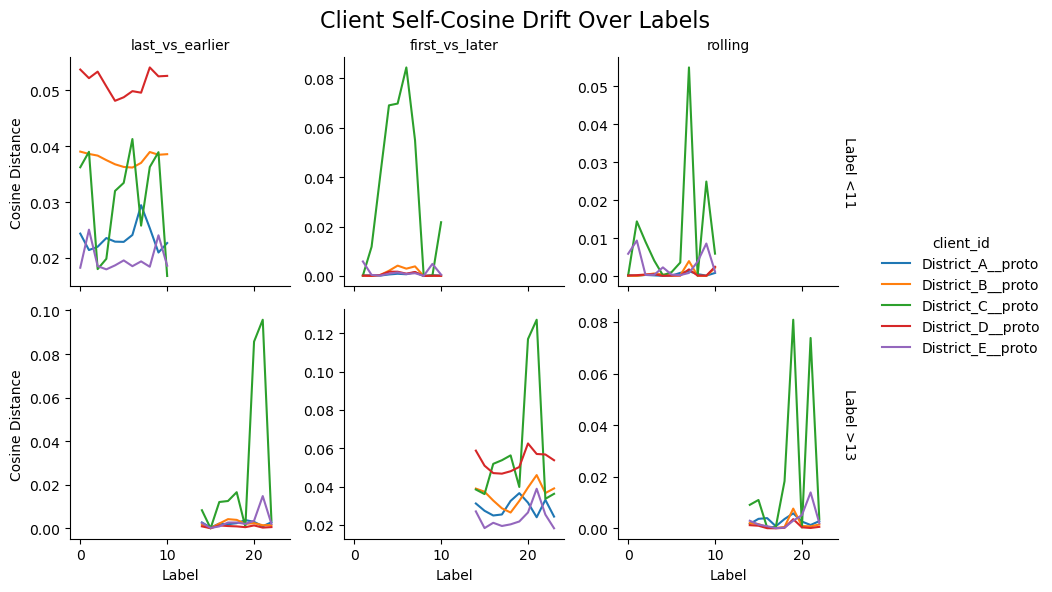



EXPERIMENT D_2_L:


100%|██████████| 15/15 [01:36<00:00,  6.46s/it]


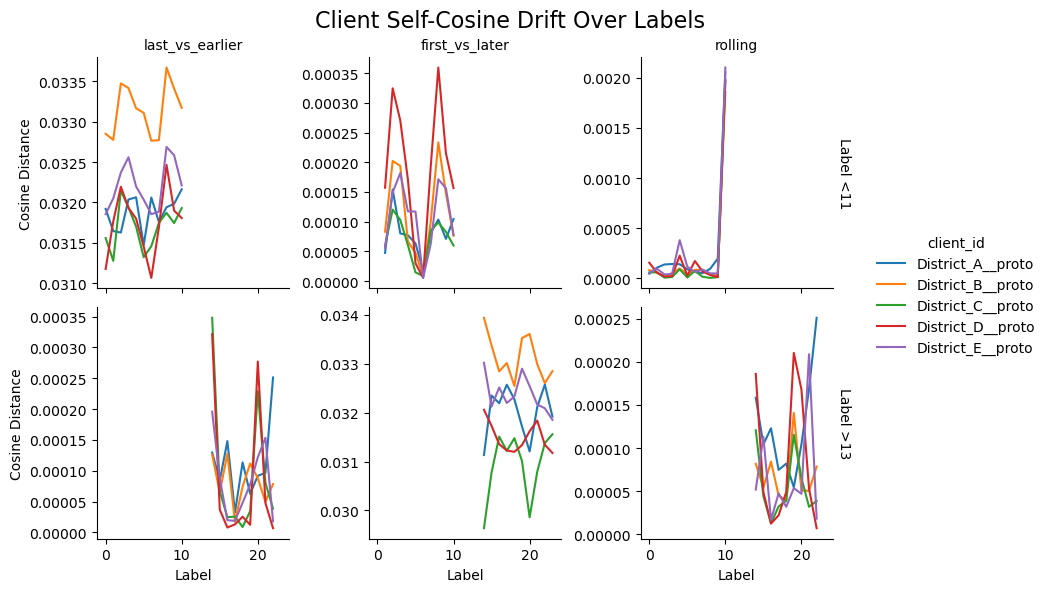



EXPERIMENT E_15_:


100%|██████████| 15/15 [01:27<00:00,  5.87s/it]


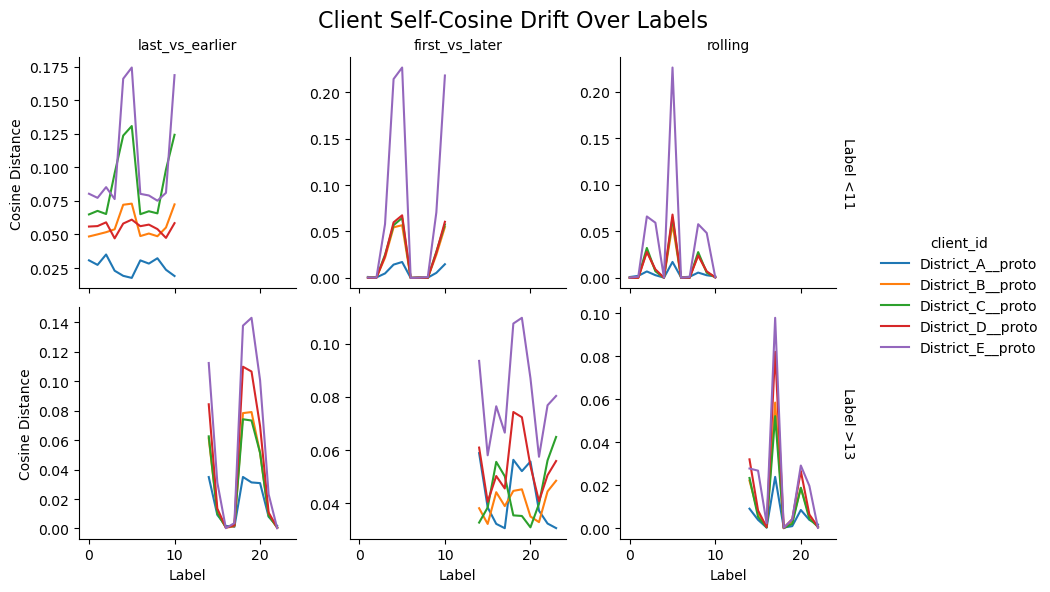

In [158]:
import warnings
warnings.filterwarnings('ignore')

for experiment in [
    'A_62_LL_LH__LL_LH_HM_MH_ML_15_1_2_12_NEW_SIMULATION_DEBUG_LL_LH_HM_MH_ML__12_6___0',
    'B_84_LL_ML__LM_LL_LH_LL_LL_15_1_2_12_NEW_SIMULATION_DEBUG_LM_LL_LH_LL_LL__12_3___0',
    'C_65_LL_LM__LL_LL_LL_LM_LH_15_1_2_12_NEW_SIMULATION_DEBUG_LL_LL_LL_LM_LH__12_3___0',
    'D_2_LL_ML__LL_LL_LM_LL_LH_15_1_2_42_NEW_SIMULATION_DEBUG_LL_LL_LM_LL_LH__42_21___0',
    'E_15_LL_LM__LL_LL_LH_LM_LL_15_1_2_12_NEW_SIMULATION_DEBUG_LL_LL_LH_LM_LL__12_6___0'
]:

    print(f'\n\nEXPERIMENT {experiment[:5]}:')
    file_path = f'results/{experiment}/results.pkl'
    
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    
    args = data['Baseline']['args']

   
    agg_int = int(args.interval_agg / 3600)
    results_id = f'{args.experiment_id}_{args.communication_epoch}_{args.local_epoch}_{agg_int}_{args.window_size}_{args.extra_coments}'
    results_dir = f"results/{results_id}"
    
    results_path = f"{results_dir}/results.pkl"
    with open(results_path, 'rb') as f:
        results = pickle.load(f)
    
    
    args = results['Baseline']['args']
    label_clients = [
        'District_A', 'District_B', 'District_C', 'District_D', 'District_E',
        'District_2A', 'District_2B', 'District_2C'
    ]
    
    priv_dataset = get_private_dataset(args)
    backbones_list = priv_dataset.get_backbone(
        parti_num=args.parti_num,
        names_list=None,
        n_series=args.input_size
    )
    
    train_DL = priv_dataset.get_data_loaders()
    base_index = train_DL[0]['X_index']
    latent_dfs = {}
    scenarios = ['Baseline']
            
    
    all_latents = defaultdict(list)
    all_protos = defaultdict(list)
    all_dists = defaultdict(list)
    all_pca = defaultdict(list)
    all_umap = defaultdict(list)
    
    for scenario in scenarios:
        global_model_history = results[scenario]['model']['global_weights_history']
        
        iterator = tqdm(range(args.communication_epoch))
        for epoch in iterator:
            aux_latents = []
            state_dict = global_model_history[epoch]
            for net in backbones_list:
                net.load_state_dict(state_dict)
    
            latent_spaces = local_evaluate(model=backbones_list,
                                           train_dl=train_DL,
                                           private_dataset=priv_dataset,
                                           group_detections=False,
                                           detect_anomalies=False)
    
            for i, client in enumerate(latent_spaces):
                client_lat = create_latent_df(
                    X_index=base_index,
                    x_lat=client,
                    label=f"{label_clients[i]}__{epoch}",
                    is_unix=True
                )
                aux_latents.append(client_lat)
    
            data_latent = pd.concat(aux_latents)
            data_latent[['client_id', 'epoch']] = data_latent['label'].str.split('__', expand=True)
    
            # Extract year and month
            years = data_latent['timestamp'].dt.year
            months = data_latent['timestamp'].dt.month
    
            # Compute base year from the minimum timestamp
            base_year = data_latent['timestamp'].min().year
    
            # Continuous month index
            data_latent['label'] = (years - base_year) * 12 + (months - 1)
    
            id_cols = ['client_id', 'label', 'epoch']
            feat_cols = [col for col in data_latent.columns if 'x_' in col]
            aux_agg = data_latent[id_cols + feat_cols]
            aux_agg = aux_agg.groupby(id_cols).mean().reset_index()
            aux_agg = aux_agg.sort_values(by=['epoch', 'label', 'client_id']).reset_index(drop=True)
            aux_agg['client_id'] += '__proto'
    
            tag = f"{scenario}_{epoch}"
            df_exp_proto = proto_analysis(data_latent=aux_agg, normalize=False)
            aux_df = df_exp_proto.copy()
            aux_df.columns = ['epoch', 'label', 'client_2', 'client_1', 'cosine', 'manhattan', 'wavelet', 'dft', 'autocorr']
            
            df_exp_proto = pd.concat([df_exp_proto, aux_df[df_exp_proto.columns.tolist()]])
            df_exp_proto = df_exp_proto.sort_values(by=['epoch', 'label', 'client_1', 'client_2']).reset_index(drop=True)
            # df_exp_proto['id'] = tag
            
            # df_exp_latent = distributions_analysis(data_distribution=data_latent[id_cols + feat_cols],
            #                                        target_client=args.tgt_district, epoch = epoch, normalize=True)
            # df_exp_latent['id'] = tag
    
            merged_latent = pd.concat([data_latent[['timestamp'] + id_cols + feat_cols], aux_agg])
            merged_latent = merged_latent.reset_index(drop=True)
    
            if args.generate_viz:
                df_latent, df_pca_scaled, df_umap_scaled = process_latent_df(
                    df_latent=merged_latent,
                    umap_neighbors=35,
                    umap_min_dist=0.85,
                    reduce_raw=False,
                    id_cols=['timestamp'] + id_cols,
                    return_scaled=False
                )
                # df_latent['id'] = tag
                df_pca_scaled['method'] = 'pca'
                df_umap_scaled['method'] = 'umap'
    
                all_latents[scenario].append(df_latent)
                all_pca[scenario].append(df_pca_scaled)
                all_umap[scenario].append(df_umap_scaled)
            else:
                # merged_latent['id'] = tag
                all_latents[scenario].append(merged_latent)
    
            all_protos[scenario].append(df_exp_proto)
            # all_dists[scenario].append(df_exp_latent)
    
    
    for scenario in scenarios:
        new_latent = pd.concat(all_latents[scenario], ignore_index=True)
        new_proto = pd.concat(all_protos[scenario], ignore_index=True)
    
    
    data_epoch = new_latent[(new_latent['epoch'] == '9') & (new_latent['client_id'].str.contains('_proto'))]
    
    df_drift = client_self_cosine_drift(data_epoch)
    
    plot_cosine_drift(df_drift)

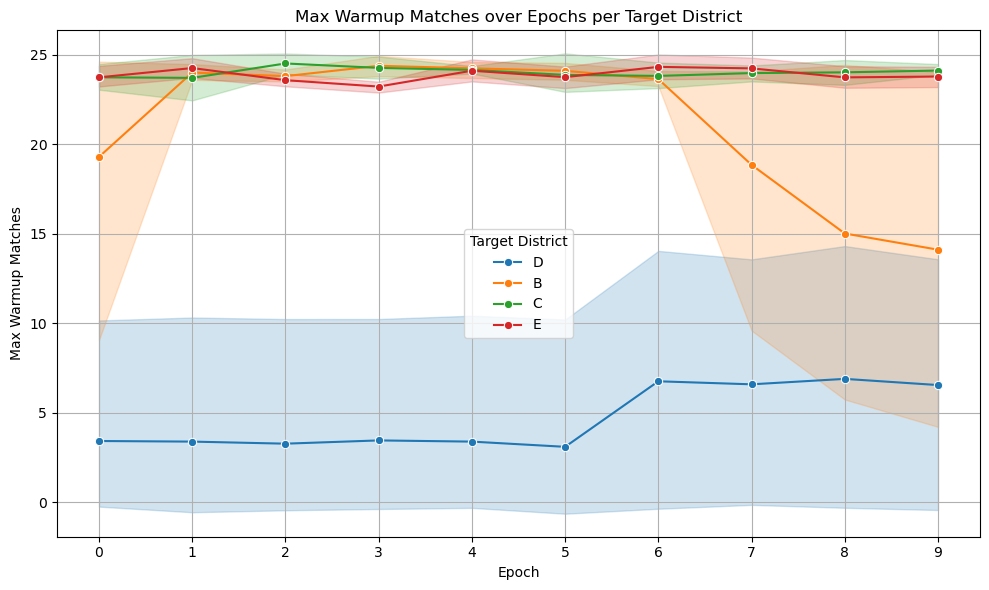

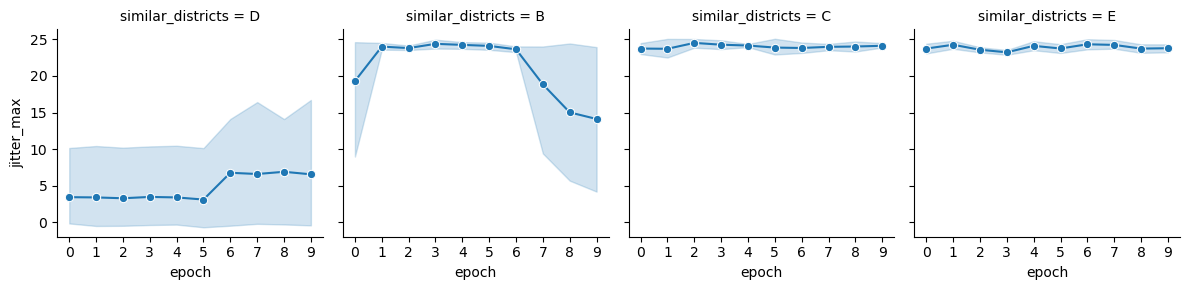

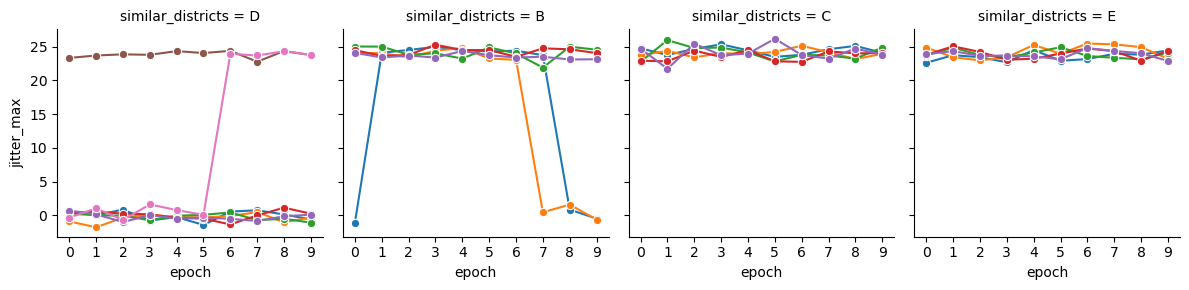

In [82]:
epochs_results_window_wavelet, best_results_window_wavelet = compute_results(experiment_id = 'NEW_WINDOW', metrics = ['wavelet'])

df_plot_window_wavelet = epochs_results_window_wavelet[epochs_results_window_wavelet['experiment'].isin(best_results_window_wavelet['experiment'])].copy()
df_plot_window_wavelet['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot_window_wavelet))]
df_plot_window_wavelet['jitter_max'] = df_plot_window_wavelet['max_final_matches'] + df_plot_window_wavelet['aux'] 

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot_window_wavelet,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot_window_wavelet, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot_window_wavelet, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )

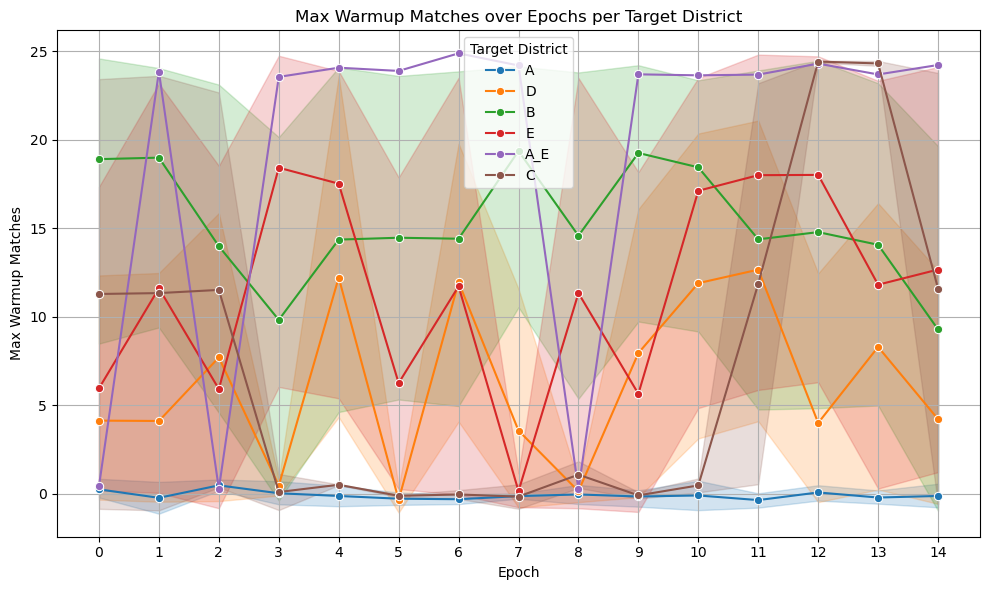

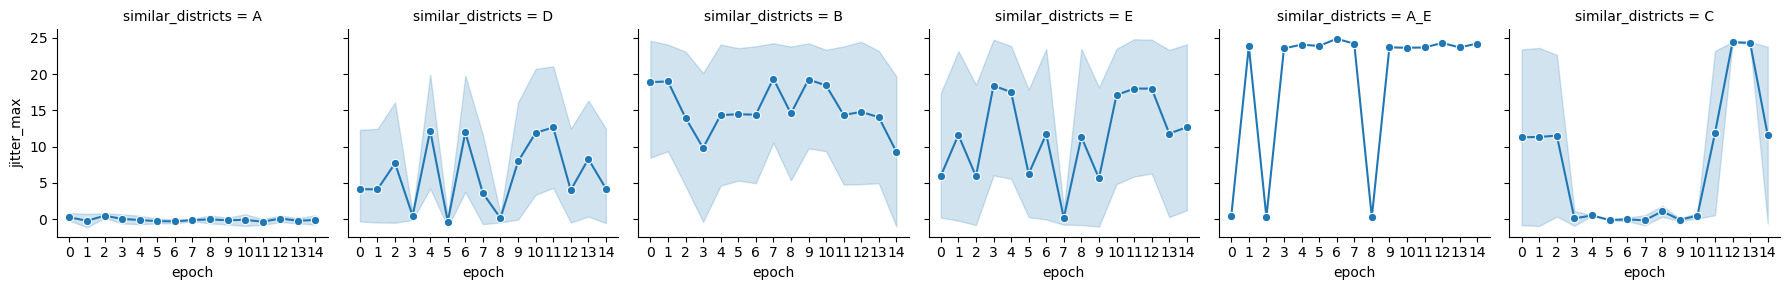

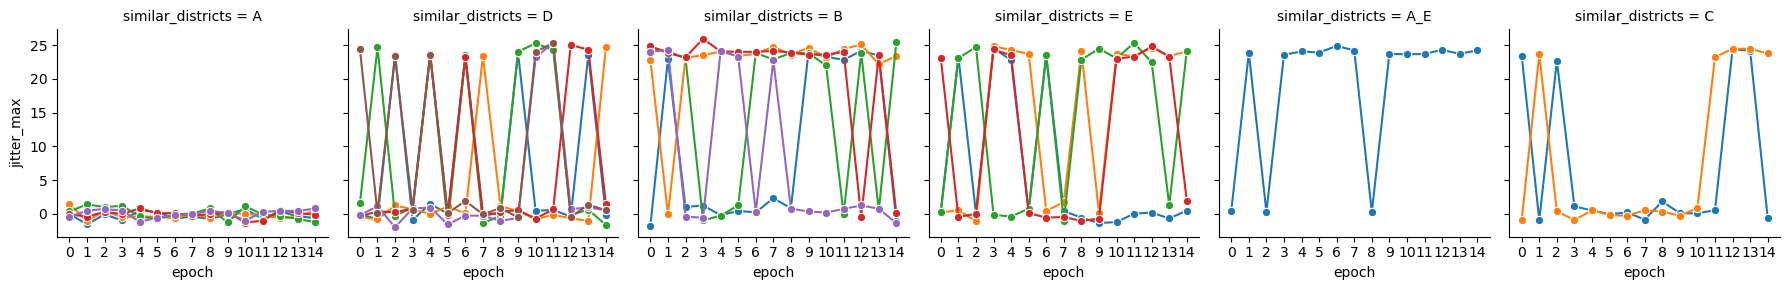

In [114]:
epochs_results_testing, best_results_testing = compute_results(experiment_id = 'NEW_TESTING', metrics = ['autocorr'])

df_plot_testing = epochs_results_testing[epochs_results_testing['experiment'].isin(best_results_testing['experiment'])].copy()
df_plot_testing['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot_testing))]
df_plot_testing['jitter_max'] = df_plot_testing['max_final_matches'] + df_plot_testing['aux'] 

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot_testing,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot_testing, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot_testing, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )

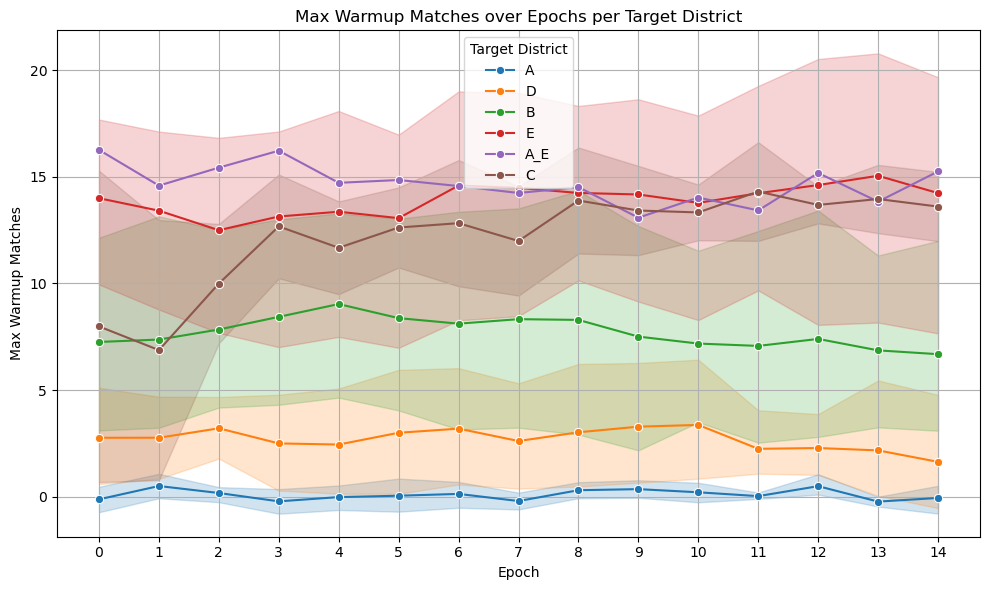

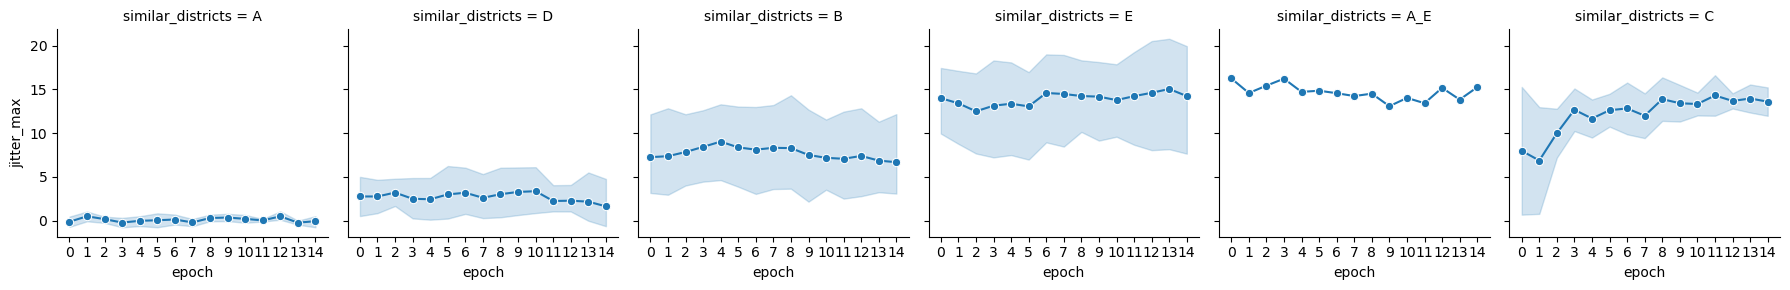

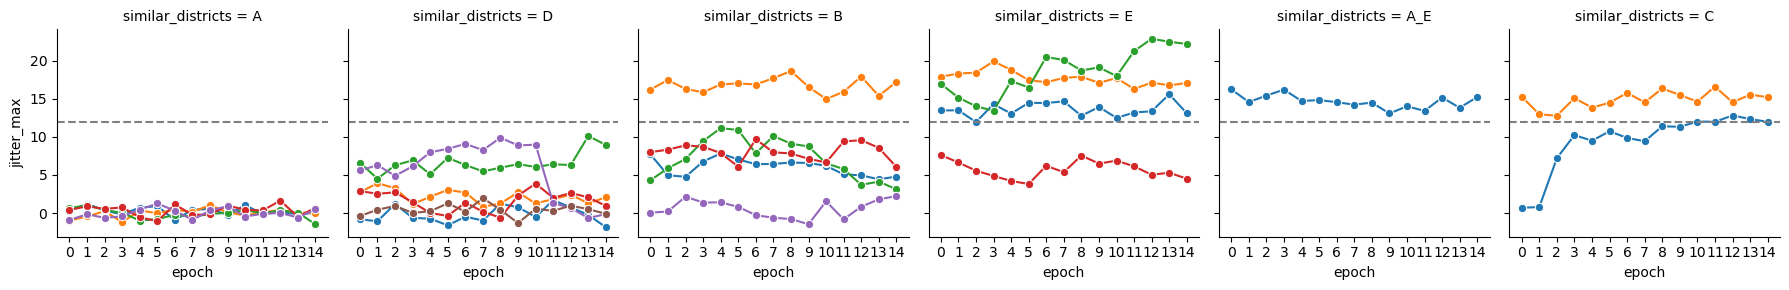

In [122]:
epochs_results_testing_cosine, best_results_testing_cosine = compute_results(experiment_id = 'NEW_TESTING', metrics = ['cosine'])

df_plot_testing_cosine = epochs_results_testing_cosine[epochs_results_testing_cosine['experiment'].isin(best_results_testing_cosine['experiment'])].copy()
df_plot_testing_cosine['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot_testing_cosine))]
df_plot_testing_cosine['jitter_max'] = df_plot_testing_cosine['max_final_matches'] + df_plot_testing_cosine['aux'] 

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot_testing_cosine,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot_testing_cosine, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot_testing_cosine, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )
g.refline(y=12)

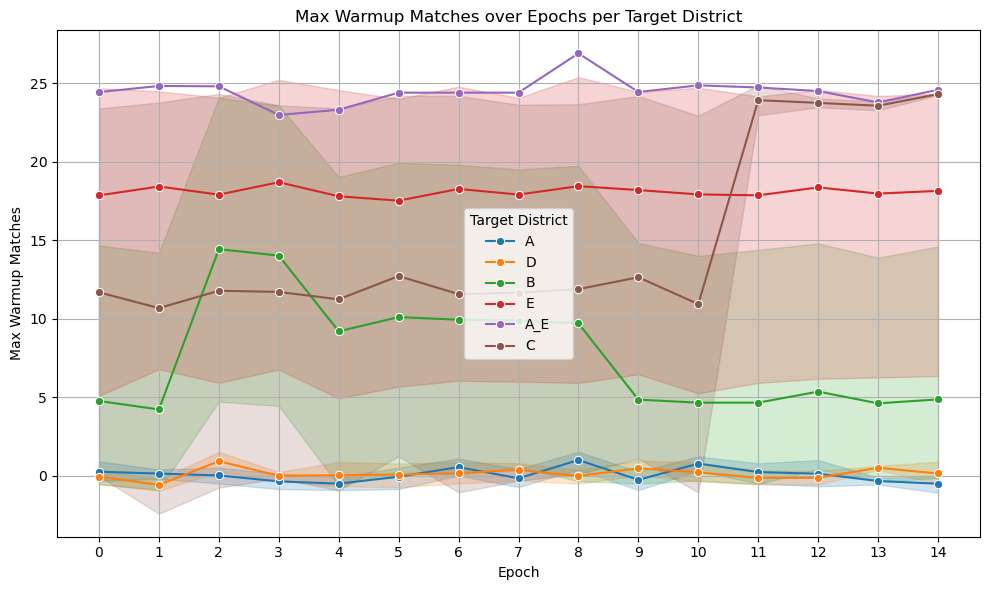

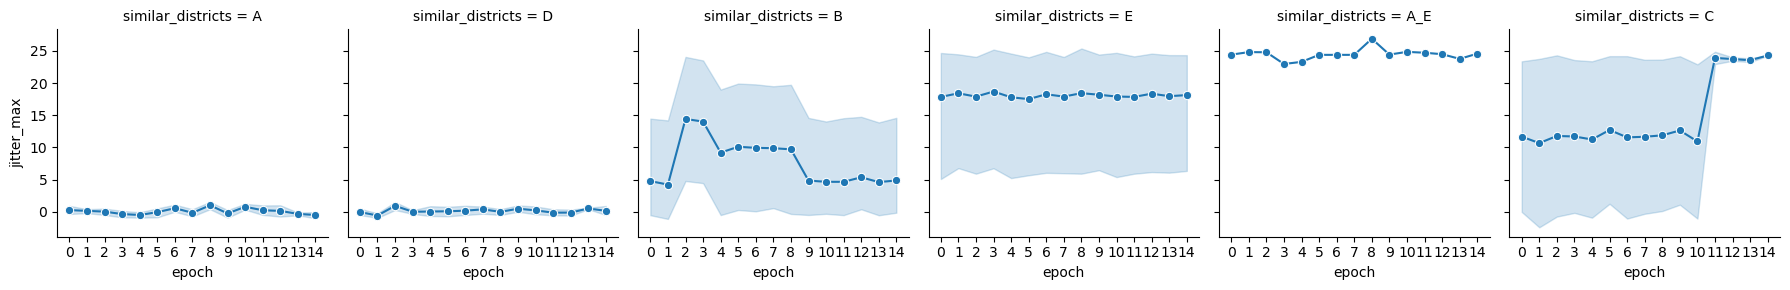

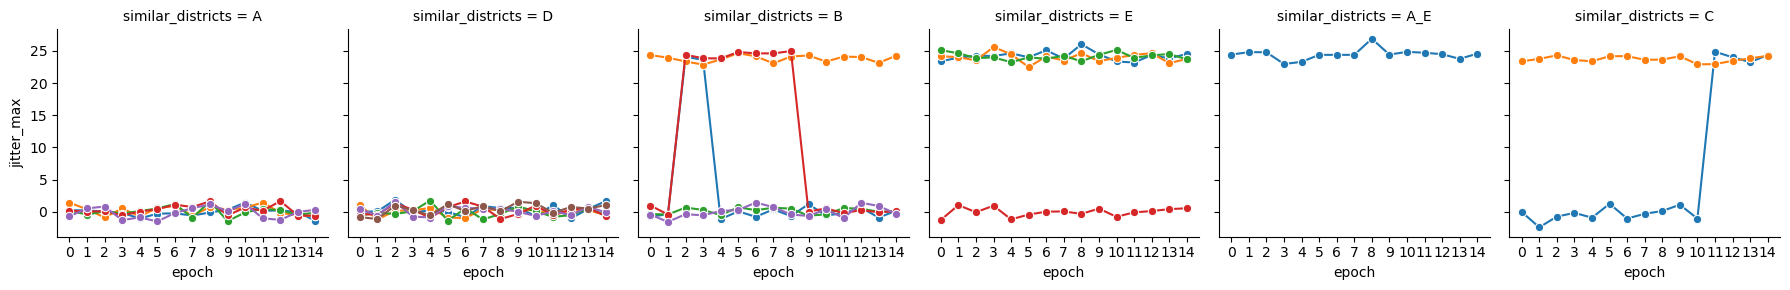

In [106]:
epochs_results_testing_dft, best_results_testing_dft = compute_results(experiment_id = 'NEW_TESTING', metrics = ['dft'])

df_plot_testing_dft = epochs_results_testing_dft[epochs_results_testing_dft['experiment'].isin(best_results_testing_dft['experiment'])].copy()
df_plot_testing_dft['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot_testing_dft))]
df_plot_testing_dft['jitter_max'] = df_plot_testing_dft['max_final_matches'] + df_plot_testing_dft['aux'] 

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot_testing_dft,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot_testing_dft, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot_testing_dft, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )

In [61]:
def get_similar_districts_from_path(path_string):
    try:
        # Split the experiment name
        parts = path_string.split('__')
        
        # Get target info
        header = parts[0]  # e.g., 'E_15_LL_LM'
        target_district = header.split('_')[0]  # 'E'
        target_init_state = header.split('_')[2]  # 'LL'
        target_final_state = header.split('_')[3]  # 'LM'

        # Get district state mapping
        state_mapping_str = parts[1]  # e.g., 'LM_LL_LM_LL_LL'
        district_states = state_mapping_str.split('_')

        # Districts in order
        district_names = ['A', 'B', 'C', 'D', 'E']

        if len(district_states) < 5:
            raise ValueError("Expected at least 5 states for districts A–E. Got: " + str(district_states))

        # Map district to state
        district_state_map = dict(zip(district_names, district_states[:5]))

        # Find similar districts (excluding the target itself)
        similar_initial = [d for d, s in district_state_map.items() if s == target_init_state and d != target_district]
        similar_final = [d for d, s in district_state_map.items() if s == target_final_state and d != target_district]

        return {
            "target_district": target_district,
            "target_init_state": target_init_state,
            "target_final_state": target_final_state,
            "initial_similar_districts": similar_initial,
            "final_similar_districts": similar_final
        }

    except Exception as e:
        print(f"Error parsing: {e}")
        return None


def analyze_experiment(results_id, results_path='results'):
    try:
        info_state = get_similar_districts_from_path(results_id)
        tgt_client = results_id[0]
        path = f"{results_path}/{results_id}/Baseline_proto.parquet"

        results_proto = pd.read_parquet(path)
        results_tgt = results_proto[results_proto['client_1'].str.contains(f'_{tgt_client}_')].drop(columns=['client_1'])

        results_tgt['cosine_rank'] = results_tgt.groupby(['epoch', 'label'])['cosine'].rank(method='dense', ascending=True)

        # remover!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        results_tgt['test_metric'] = results_tgt['cosine'] + results_tgt['autocorr']
        results_tgt['cosine_rank'] = results_tgt.groupby(['epoch', 'label'])['test_metric'].rank(method='dense', ascending=True)


        top_ranked = results_tgt[results_tgt['cosine_rank'] == 1]

        summary = top_ranked.groupby(['epoch', 'label', 'client_2']).size().reset_index(name='count')
        summary['district_letter'] = summary['client_2'].str.extract(r'District_([A-Z])')

        summary['epoch'] = pd.to_numeric(summary['epoch'], errors='coerce')
        summary['label'] = pd.to_numeric(summary['label'], errors='coerce')
        summary = summary.dropna(subset=['district_letter', 'epoch', 'label'])

        # Final-only match
        summary['match_final_only'] = summary['district_letter'].isin(info_state['final_similar_districts'])

        # Warm-up rule
        def match_with_warmup(row):
            if row['label'] < 3:
                return row['district_letter'] in info_state['initial_similar_districts']
            else:
                return row['district_letter'] in info_state['final_similar_districts']

        summary['match_warmup_rule'] = summary.apply(match_with_warmup, axis=1)

        # Summarize results
        total_final = summary['match_final_only'].sum()
        total_warmup = summary['match_warmup_rule'].sum()

        matches_per_epoch = summary.groupby('epoch')[['match_final_only', 'match_warmup_rule']].sum().reset_index()
        max_final = matches_per_epoch['match_final_only'].max()
        max_warmup = matches_per_epoch['match_warmup_rule'].max()

        matches_per_epoch['experiment'] = results_id
        matches_per_epoch['max_final_matches'] = max_final
        matches_per_epoch['max_warmup_matches'] = max_warmup

        # return matches_per_epoch

        return {
            'experiment': results_id,
            'total_final_matches': total_final,
            'total_warmup_matches': total_warmup,
            'max_final_matches': max_final,
            'max_warmup_matches': max_warmup
        }

    except Exception as e:
        return {'experiment': results_id, 'error': str(e)}


In [69]:
CASE_TGT = 'NEW_WINDOW'

In [75]:
import pandas as pd
import os
import glob
from collections import defaultdict

results_path = 'results'

# Get all folder paths
folders_with_rep = [f for f in glob.glob(os.path.join(results_path, F'*{CASE_TGT}*')) if os.path.isdir(f)]

# Group by base experiment (strip off last suffix)
grouped_exps = defaultdict(list)
for path in folders_with_rep:
    folder_name = os.path.basename(path)
    if '__' in folder_name:
        base = '__'.join(folder_name.split('__')[:-1])
        grouped_exps[base].append(path)
    else:
        grouped_exps[folder_name].append(path)

# Run analysis for each experiment folder
all_results = []
for base_name, group_paths in grouped_exps.items():
    for path in group_paths:
        exp_name = os.path.basename(path)
        result = analyze_experiment(exp_name, results_path=results_path)
        all_results.append(result)


df_results = pd.DataFrame(all_results)

def extract_exp_info(exp_id):
    try:
        parts = exp_id.split('__')
        target_header = parts[0]                     # 'E_15_LL_LM'
        mapping = parts[1]                           # 'LM_LL_LM_LL_LL'

        target_district = target_header.split('_')[0]     # 'E'
        node_id = target_header.split('_')[1]             # '15'
        init_state = target_header.split('_')[2]          # 'LL'
        final_state = target_header.split('_')[3]         # 'LM'

        aux_exp1 = exp_id.split('__')[-1]
        aux_exp2 = exp_id.split('__')[-2]

        return pd.Series([
            f"{target_district}_{node_id}",         # 'E_15'
            f"{init_state}_{final_state}",          # 'LL_LM'
            mapping[:14],                                 # 'LM_LL_LM_LL_LL'
            f"{aux_exp2}_{aux_exp1}"
        ])
    except Exception as e:
        print(f"Failed parsing exp_id: {exp_id} — {e}")
        return pd.Series([None, None, None])

df_results[['target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']] = (
    df_results['experiment'].apply(extract_exp_info)
)


# Get max warmup match for each unique config
idx = df_results.groupby(
    ['target_district_node', 'target_init_final_state', 'initial_state_mapping']
)['total_final_matches'].idxmax()

df_best_per_config = df_results.loc[idx].reset_index(drop=True)

# Optional: sort by warmup performance
df_best_per_config = df_best_per_config.sort_values(by='total_final_matches', ascending=False)

df_best_per_config['correct_epochs'] = df_best_per_config['total_final_matches'] / 24
df_best_per_config['target_district'] = df_best_per_config['target_district_node'].str.split('_').str[0]
df_best_per_config['target_final_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-1]

df_best_per_config[['A', 'B', 'C', 'D', 'E']] = df_best_per_config['initial_state_mapping'].str.split('_', expand = True)

df_best_per_config.drop(columns = ['target_district_node', 'initial_state_mapping', 'target_init_final_state'], inplace = True)

def find_similar(row):
    match_cols = [col for col in ['A', 'B', 'C', 'D', 'E'] if row[col] == row['target_final_state']]
    return '_'.join(match_cols)

df_best_per_config['similar_districts'] = df_best_per_config.apply(find_similar, axis=1)

# Show results
print("🏆 Best experiment per configuration (based on warm-up matches):")
# df_best_per_config[['experiment', 'total_final_matches', 'target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']]
df_best_per_config[df_best_per_config['similar_districts'] != '']

🏆 Best experiment per configuration (based on warm-up matches):


,experiment,total_final_matches,total_warmup_matches,max_final_matches,max_warmup_matches,exp_id,correct_epochs,target_district,target_final_state,A,B,C,D,E,similar_districts
21,A_62_LL_LM__LL_MM_HL_ML_LM_10_1_4_3_NEW_WINDOW...,238,209,24,21,3_1_14400__0,9.916667,A,LM,LL,MM,HL,ML,LM,E
19,A_62_LL_LM__LL_LM_LH_LL_LL_10_1_6_3_NEW_WINDOW...,220,196,24,21,3_2_21600__0,9.166667,A,LM,LL,LM,LH,LL,LL,B
6,A_62_LL_LH__LL_LL_LL_LM_LH_10_1_12_6_NEW_WINDO...,214,192,24,21,6_4_43200__0,8.916667,A,LH,LL,LL,LL,LM,LH,E
1,A_62_LL_LH__LL_LH_HM_MH_ML_10_1_4_6_NEW_WINDOW...,192,170,24,21,6_3_14400__0,8.000000,A,LH,LL,LH,HM,MH,ML,B
23,A_62_LL_ML__LL_LH_HM_MH_ML_10_1_12_9_NEW_WINDO...,189,166,24,21,9_4_43200__0,7.875000,A,ML,LL,LH,HM,MH,ML,E
4,A_62_LL_LH__LL_LL_LH_LM_LL_10_1_4_9_NEW_WINDOW...,182,166,24,21,9_4_14400__0,7.583333,A,LH,LL,LL,LH,LM,LL,C
2,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_6_3_NEW_WINDOW...,161,149,24,21,3_2_21600__0,6.708333,A,LH,LL,LH,LL,LL,LM,B
3,A_62_LL_LH__LL_LH_LM_LL_LL_10_1_6_9_NEW_WINDOW...,159,141,24,21,9_6_21600__0,6.625000,A,LH,LL,LH,LM,LL,LL,B
14,A_62_LL_LM__LL_LH_LM_LL_LL_10_1_6_9_NEW_WINDOW...,157,133,24,21,9_4_21600__0,6.541667,A,LM,LL,LH,LM,LL,LL,C
7,A_62_LL_LH__LL_LL_LM_LH_LL_10_1_4_3_NEW_WINDOW...,152,142,24,21,3_1_14400__0,6.333333,A,LH,LL,LL,LM,LH,LL,D


In [2]:
import warnings
from argparse import ArgumentParser

import pandas as pd

from datasets import Priv_NAMES as DATASET_NAMES
from datasets import get_private_dataset
from models import get_all_models
from models import get_model
from utils.Server import train
from utils.Toolbox_analysis import create_latent_df, process_latent_df

warnings.simplefilter(action='ignore', category=FutureWarning)


def parse_args():
    parser = ArgumentParser(description='You Only Need Me', allow_abbrev=False)
    parser.add_argument('--device_id', type=int, default=0, help='The Device Id for Experiment')
    parser.add_argument('--communication_epoch', type=int, default=10,
                        help='The Communication Epoch in Federated Learning')
    parser.add_argument('--local_epoch', type=int, default=3,
                        help='The Local Epoch for each Participant')

    parser.add_argument('--experiment_id', type=str,
                        default='A_62_LL_LM__LL_LM_LH_LL_LL', help='Experiment identifier')
    parser.add_argument('--extra_coments', type=str,
                        default='NEW_TESTING_LL_HM_LM_MM_LL__24_6___0', help='Aditional info')

    # Data parameter
    parser.add_argument('--dataset', type=str, default='fl_leaks', choices=DATASET_NAMES,
                        help='Which scenario to perform experiments on.')
    parser.add_argument('--domains', type=dict, default={'Graeme': 5}, # TODO REFACTOR TYPE
                        help='Domains and respective number of participants.')

    ## Time series preprocessing
    parser.add_argument('--interval_agg', type=int, default=4 * 60 ** 2,
                        help='Agregation interval (seconds) of time series')
    parser.add_argument('--window_size', type=int, default=1,
                        help='Rolling window length')
    parser.add_argument('--step_size', type=int, default=1,
                        help='Rolling window step size')

    # Model (AER) parameters
    parser.add_argument('--input_size', type=int, default=5,
                        help='Number of sensors')  # TODO adaptar
    parser.add_argument('--output_size', type=int, default=5,
                        help='Shape output - dense layer')
    parser.add_argument('--lstm_units', type=int, default=30,
                        help='Number of LSTM units (the latent space will have dimension 2 times bigger')

    # Participants info
    parser.add_argument('--parti_num', type=int, default=None,
                        help='The Number for Participants. If "None" will be setted as the sum of values described in --domain')
    parser.add_argument('--online_ratio', type=float, default=1,
                        help='The Ratio for Online Clients')

    # Federated parameters
    parser.add_argument('--model', type=str, default='fpl',
                        help='Federated Model name.', choices=get_all_models()) #fedavg
    parser.add_argument('--structure', type=str, default='homogeneity')
    parser.add_argument('--pri_aug', type=str, default='weak',  # weak strong
                        help='Augmentation for Private Data')
    parser.add_argument('--learning_decay', type=bool, default=False,
                        help='The Option for Learning Rate Decay')
    parser.add_argument('--averaging', type=str, default='weight',
                        help='The Option for averaging strategy')

    parser.add_argument('--infoNCET', type=float, default=0.02,
                        help='The InfoNCE temperature')
    parser.add_argument('--T', type=float, default=0.05,
                        help='The Knowledge distillation temperature')
    parser.add_argument('--weight', type=int, default=1,
                        help='The Weigth for the distillation loss')


        # Time variables
    parser.add_argument('--n_segments', type=int, default=12,
                        help='Number of urban growth simulation segments.')
    parser.add_argument('--epochs_lenght', type=int, default=6,
                        help='Number of epochs per simulation run.')
    parser.add_argument('--days_lenght', type=int, default=5,
                        help='Number of days in each epoch.')
    parser.add_argument('--n_intervals', type=int, default=24,
                        help='Number of time intervals per day.')

    # Hydraulic variables
    parser.add_argument('--unit', type=str, default='l/s',
                        help='Measurement unit for flow.')
    parser.add_argument('--leak_severity', type=float, default=0.15,
                        help='Leak severity multiplier.')

    args, unknown = parser.parse_known_args()

    if args.parti_num is None:
        args.parti_num = sum(args.domains.values())
    #
    # best = best_args[args.dataset][args.model]
    #
    # for key, value in best.items():
    #     setattr(args, key, value)
    #
    # if args.seed is not None:
    #     set_random_seed(args.seed)

    return args

In [3]:
import pandas as pd
import numpy as np
from numpy import ndarray

import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter

def get_majority_month_label(windows_timestamps, threshold=0.7):
    """
    Assign continuous month labels (e.g., Jan Year 0 = 0, Jan Year 1 = 12)
    based on majority in each window.

    Parameters:
        windows_timestamps: array-like of shape (num_windows, window_size)
        threshold: float - required fraction of timestamps in one month

    Returns:
        labels: list of int (continuous month indices) or None if threshold not met
        mask: numpy array of bool, True where threshold met
    """
    labels = []
    mask = []

    # Flatten all timestamps to find the earliest year
    all_timestamps = np.concatenate(windows_timestamps)
    all_datetimes = pd.to_datetime(all_timestamps, unit='s')
    base_year = all_datetimes.min().year

    for window in windows_timestamps:
        dt_index = pd.to_datetime(window, unit='s')
        months = dt_index.month
        years = dt_index.year
        # Continuous month index
        continuous_months = (years - base_year) * 12 + (months - 1)

        counts = Counter(continuous_months)
        majority_month, majority_count = counts.most_common(1)[0]
        fraction = majority_count / len(window)

        if fraction >= threshold:
            labels.append(majority_month)
            mask.append(True)
        else:
            labels.append(None)
            mask.append(False)

    return labels, np.array(mask)
    
def prepare_data(args, X: np.ndarray, X_index: np.ndarray, y: np.ndarray = None):
    """
    Prepares PyTorch DataLoader from input data, including hour-based label.
    """


    # # Extract 12-hour format label from timestamps
    # timestamps = pd.to_datetime(X_index, unit='s')
    # # hour = timestamps.hour
    # # label = hour.where(hour < 12, hour - 12).to_numpy()
    # # label = label / args.agg_interval
    # month = timestamps.month - 1
    # label = month.to_numpy()
    # label_tensor = torch.tensor(label, dtype=torch.int64)  # or float32 if needed

    labels, mask = get_majority_month_label(windows_timestamps=X_index, threshold=0.75)
    label_filtered = [l for l in labels if l is not None]
    label_tensor = torch.tensor(label_filtered, dtype=torch.int64)

    X_filtered = X[mask].copy()

    if y is None:
        y = X_filtered.copy()

    # Prepare input and targets
    X_filtered = X[mask].copy()

    if X_filtered.shape[1] < 3:
        raise ValueError(f"Window size too small after filtering: {X_filtered.shape[1]} (need at least 3)")

    # Optionally adjust the slicing if necessary
    X_filtered = X_filtered[:, 1:-1, :]

    ry, y, fy = y[:, 0], y[:, 1:-1], y[:, -1]

    X_tensor = torch.tensor(X_filtered, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    ry_tensor = torch.tensor(ry, dtype=torch.float32).unsqueeze(-1)
    fy_tensor = torch.tensor(fy, dtype=torch.float32).unsqueeze(-1)

    # Add label tensor to dataset
    dataset = torch.utils.data.TensorDataset(X_tensor, ry_tensor, y_tensor, fy_tensor, label_tensor)


    return dataset
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

    return dataloader

In [52]:
for window in [84, 168, 360, 720, 1080]:
    for interval in [2, 3, 4]:
        print(f'{interval}h * {window} -> {interval * window / 24} dias')
    print()

2h * 84 -> 7.0 dias
3h * 84 -> 10.5 dias
4h * 84 -> 14.0 dias

2h * 168 -> 14.0 dias
3h * 168 -> 21.0 dias
4h * 168 -> 28.0 dias

2h * 360 -> 30.0 dias
3h * 360 -> 45.0 dias
4h * 360 -> 60.0 dias

2h * 720 -> 60.0 dias
3h * 720 -> 90.0 dias
4h * 720 -> 120.0 dias

2h * 1080 -> 90.0 dias
3h * 1080 -> 135.0 dias
4h * 1080 -> 180.0 dias



In [5]:
args = parse_args()
scenario = 'Baseline'

DLS = []
for window in [84, 168, 360]:
    for step in [0.25 * window, 0.5 * window, 0.75 * window]:
        for interval in [2]:
            # try:
            args.interval_agg = interval * 3600
            args.window_size = window
            args.step_size = int(step)  # step is float; cast to int if needed

            priv_dataset = get_private_dataset(args)
            priv_train_loaders = priv_dataset.get_data_loaders(scenario=scenario)
            
            backbones_list = priv_dataset.get_backbone(
                parti_num=args.parti_num,
                names_list=None,
                n_series=args.input_size
            )

            model = get_model(backbones_list, args, priv_dataset)

            priv_train_loaders = priv_dataset.get_data_loaders(scenario='Baseline')

            loader = priv_train_loaders[0]
            print(f"\nParameters:\tW={window}\tS={int(step)}\tA={interval}")
            print("Loader lengths:", len(loader['X']), len(loader['X'][0]))

            dl = prepare_data(args = args, X = loader['X'], X_index = priv_train_loaders[0]['win_idx'], y = None)
            DLS.append(dl)
            # except Exception as e:
            #     print(f"[ERROR] Failed for window={window}, step={step}, interval={interval}")
            #     print("Error:", e)
            #     continue  # skip to next loop iteration


Parameters:	W=84	S=21	A=2
Loader lengths: 408 84

Parameters:	W=84	S=42	A=2
Loader lengths: 204 84

Parameters:	W=84	S=63	A=2
Loader lengths: 136 84

Parameters:	W=168	S=42	A=2
Loader lengths: 202 168

Parameters:	W=168	S=84	A=2
Loader lengths: 101 168

Parameters:	W=168	S=126	A=2
Loader lengths: 68 168

Parameters:	W=360	S=90	A=2
Loader lengths: 93 360

Parameters:	W=360	S=180	A=2
Loader lengths: 47 360

Parameters:	W=360	S=270	A=2
Loader lengths: 31 360


In [113]:
DLS

In [10]:
for i, ds in enumerate(DLS):
    print(f"Dataset {i} length: {len(ds)}")

Dataset 0 length: 365
Dataset 1 length: 181
Dataset 2 length: 120
Dataset 3 length: 159
Dataset 4 length: 78
Dataset 5 length: 53
Dataset 6 length: 49
Dataset 7 length: 24
Dataset 8 length: 17


In [12]:
loader['X_raw'].shape

(8641, 5)

In [14]:
[t / 3600 for t in loader['X_index'][:10]]

[0.0, 540.0, 1080.0, 1620.0, 2160.0, 2700.0, 3240.0, 3780.0, 4320.0, 4860.0]

In [28]:
L = 360*2*24
L

17280

In [30]:
g = 2
M = L/ g
M

8640.0

In [36]:
W = 360
S = 90

N = (M - W + 1) / S
N

92.0111111111111

In [38]:
[l/(3600*24) for l in loader['X_index'][:10]]

[0.0, 22.5, 45.0, 67.5, 90.0, 112.5, 135.0, 157.5, 180.0, 202.5]